In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.axes3d import Axes3D
import pandas as pd
import time 
import copy
import random
import math
from sklearn.model_selection import train_test_split


# 產生點雲圖

Starting to read the raw data!
Raw data reading done!
vali_3.csv
Raw data got 2880000 points.
 
Starting dimension reduction via voxel filtering!
Voxel size = 0.6
Dimension reduction done!
7816 points in total.
Time consumed for raw data reading : 29.409737586975098


C:\Users\mmdl\.conda\envs\keras\lib\site-packages\ipykernel_launcher.py:144: MatplotlibDeprecationWarning: Axes3D(fig) adding itself to the figure is deprecated since 3.4. Pass the keyword argument auto_add_to_figure=False and use fig.add_axes(ax) to suppress this warning. The default value of auto_add_to_figure will change to False in mpl3.5 and True values will no longer work in 3.6.  This is consistent with other Axes classes.


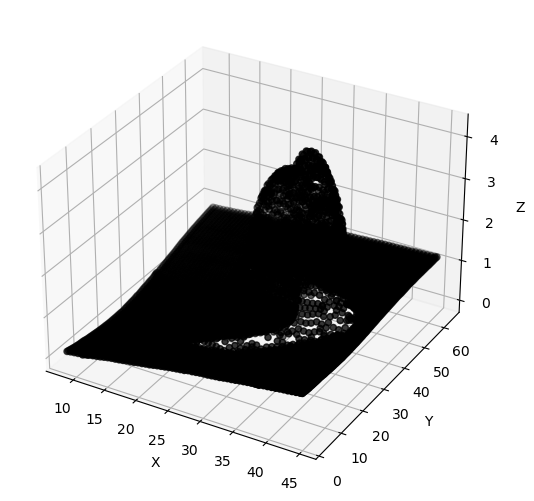

In [2]:
#dimension reduction
#https://blog.51cto.com/u_15067236/4351230
print("Starting to read the raw data!")
file = "vali_3.csv"
path = r"C:/Users/mmdl/Desktop/Jiayuan/jy_files/"   #C:/Users/mmdl/Desktop/weld_seam_data/ #D:/USER/Desktop/files/weld_seam_data/ 
scan_lenght = 63.5*np.pi*(4/12)  #63.5*np.pi*(4/12)
n_section = 100     #70
data_raw = pd.read_csv(path+file)

time1 = time.time()  #計時器1
z = []    #高度 後面用於標準差篩選去除夾具
a = []    #用來定義標準差範圍
for i in range(0, len(data_raw.values)):
    a.append(np.std(data_raw.values[i]))     #計算每一行的標準差並加入a內(單純為了要定義thre)
thre = math.ceil(np.mean(a)/10)*10           #****定義一個thre作為標準
                                             #取a內的平均值除10並向上取最接近整數再*10
#利用標準差篩選夾具等等不要的範圍
for i in range(0, len(data_raw.values)): 
#    if np.std(data_raw.values[i]) < thre:    #若該行的標準差小於thre
    z.append(data_raw.values[i])         #則添加至z中 篩選後的資料
    
point = []  #每個點的X,Y,高度

for i in range(0, len(z), 10):               #在z資料中 每隔10行取一次資料
    for j in range(0, len(z[i])):
        point.append([j/3200*39+6.925, i/9000*scan_lenght, z[i][j]])  #計算x,y,z值並組成列表加入point中  6.925為自己調出來的

print("Raw data reading done!")
print(file)
print("Raw data got", str(len(point)), "points.")
print(" ")
print("Starting dimension reduction via voxel filtering!")

filtered_points = []

tempx = []
tempy = []
tempz = []
for i in range(0, len(point)):
    tempx.append(point[i][0])       #用於儲存point中的x值
    tempy.append(point[i][1])       #用於儲存point中的y值
    tempz.append(point[i][2])       #用於儲存point中的z值
    
x_max = np.max(tempx)               #計算x,y,z的最大與最小值
y_max = np.max(tempy)
z_max = np.max(tempz)
x_min = np.min(tempx)
y_min = np.min(tempy)
z_min = np.min(tempz)

#setting the size of voxels, the bigger size leads to the lower resolution
size_v = 0.6            #設定體素大小為0.6
print("Voxel size =", str(size_v))

d_x = (x_max-x_min)/size_v    #計算要多少體素才能包含所有範圍  ex. 最大為10 最小為0  體素大小為1  可以得知(10-0)/1=10個體數
d_y = (y_max-y_min)/size_v
d_z = (z_max-z_min)/size_v

h = []  #用來儲存XYZ第幾個體素
for i in range(0, len(point)):
    hx = np.floor((point[i][0] - x_min) / size_v)   #floor(向下取整數) 投影到X座標  該點減去min計算在第幾個體素
    hy = np.floor((point[i][1] - y_min) / size_v)   #投影到Y座標
    hz = np.floor((point[i][2] - z_min) / size_v)   #投影到Z座標
    h.append(hx + hy*d_x + hz*d_x*d_y)              #****  線性索引


h = np.array(h)
index_h = np.argsort(h)   #對h陣列做排序
h_sorted = h[index_h]     #把排序後的陣列內的元素儲存至h_sorted
count = 0
np.seterr(divide='ignore', invalid='ignore')  #遇到一些錯誤 如分母為0時跳過不計算


'''
#random filtering
for i in range(0, len(h_sorted)-1):
    if h_sorted[i] == h_sorted[i+1]:
        continue
    index_point = index_h[count:i+1]
    d = random.choice(index_point)
    filtered_points.append(point[d])
    count = i
'''
#centroid filtering
for i in range(0, len(h_sorted)-1):
    if h_sorted[i] == h_sorted[i+1]:       #若同一個體數 該次就不跑直接跑下一次
        continue
    index_point = index_h[count:i+1]
    x_temp = []
    y_temp = []
    z_temp = []
    for p in index_point:
        x_temp.append(point[p][0])         
        y_temp.append(point[p][1])
        z_temp.append(point[p][2])
    filtered_points.append([np.mean(x_temp), np.mean(y_temp), np.mean(z_temp)])   #將x,y,z分別做平均 作為質心點
    count = i
    
filtered_points = np.array(filtered_points, dtype=np.float64)

x_f = []
y_f = []
z_f = []

for i in range(0, len(filtered_points)):
    x_f.append(filtered_points[i][0])
    y_f.append(filtered_points[i][1])
    z_f.append(filtered_points[i][2])

time3 = time.time()  #第三計時器

# replace the outlier points with some middle points
# points lying in the egde of the workpiece are also picked out



for i in range(0, len(filtered_points)):       #這段是避免上面還有未濾波完的 再詳細去除我們不要的
    if z_f[i] < -3 or z_f[i] > 30:
        x_f[i] = 0
        y_f[i] = 0
        z_f[i] = 0
        
    if (y_f[i] > np.max(y_f)-1) or (y_f[i] < np.min(y_f)+1):     #避免工件兩側掃描模糊  直接將掃描結果內縮
        x_f[i] = 0
        y_f[i] = 0
        z_f[i] = 0

while (0 in x_f):                  #去除剛剛變成0的值
    x_f.remove(0)
    y_f.remove(0)
    z_f.remove(0)
    
y_lim = np.min(y_f)                  #原高數值可能為-1 低為-3  同減去最小值-3  可得高為2 低為0  有點轉換的意味
# for i in range(0, len(y_f)):
y_f = y_f - y_lim          #將yf的最小值變成0 方便觀看而已
# x_f = x_f - np.min(x_f)
z_f = z_f - np.min(z_f)

print("Dimension reduction done!")
print(str(len(x_f)), "points in total.")

fig = plt.figure()    #創建圖形物件

ax = Axes3D(fig)   #創建一個3D物件並加入到fig
fig.add_axes(ax)

ax.set_ylim([0, scan_lenght])   #座標比例尺
#****

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

ax.scatter(x_f, y_f, z_f, c ='black')

time2 = time.time()    #計時器2
print("Time consumed for raw data reading :", (time2-time1))
plt.show()

In [3]:
# xtest = []
# ztest = []

# start = 59
# for i in range(len(y_f)):
#     if y_f[i] > start and y_f[i] < start+0.6:
#         xtest.append(x_f[i])
#         ztest.append(z_f[i])

# plt.scatter(xtest, ztest, s = 60, c = 'blue', label = 'c1')

# plt.show()


# 產生銲道剖面資料集

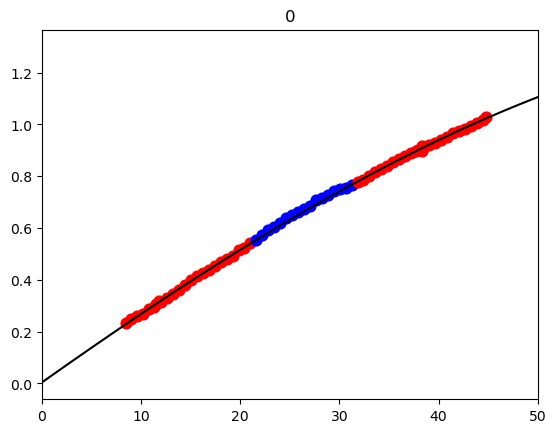

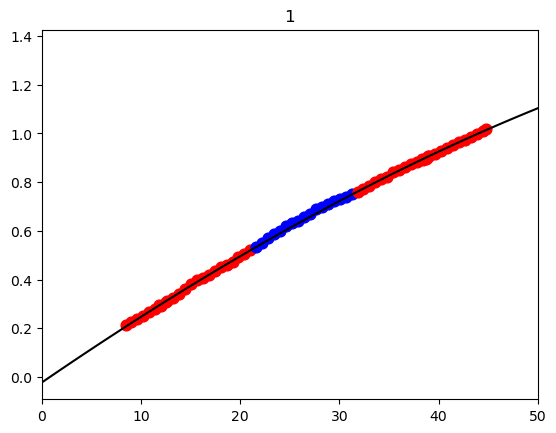

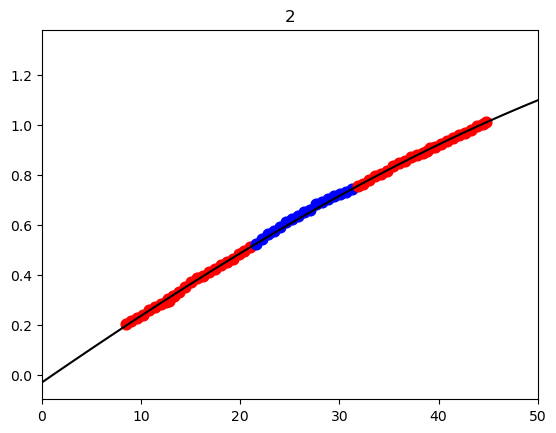

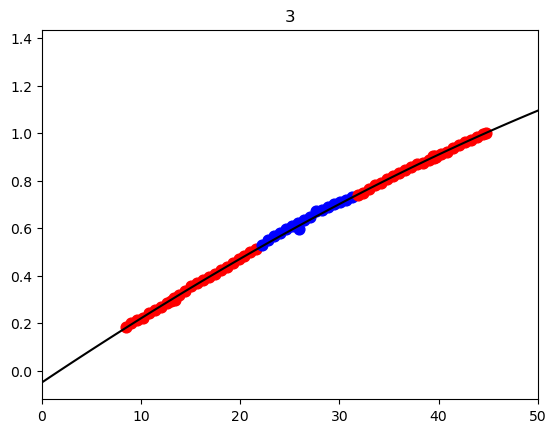

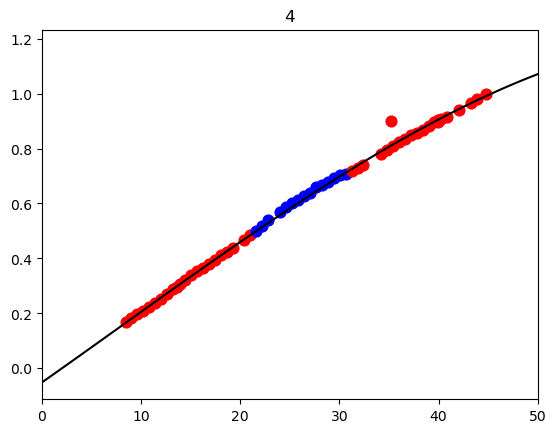

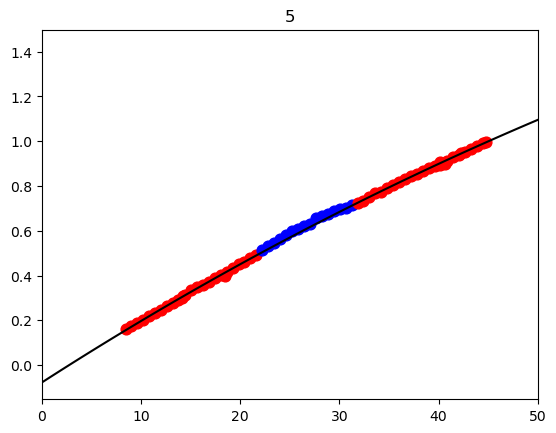

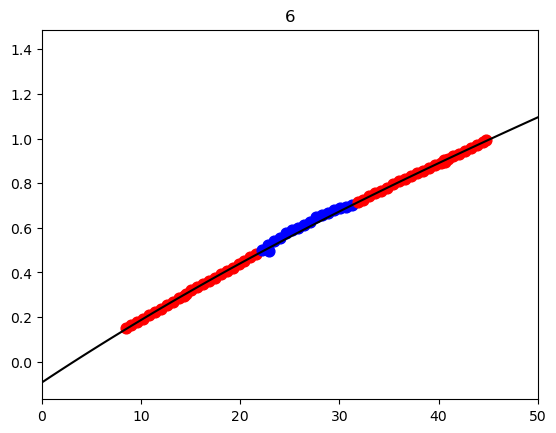

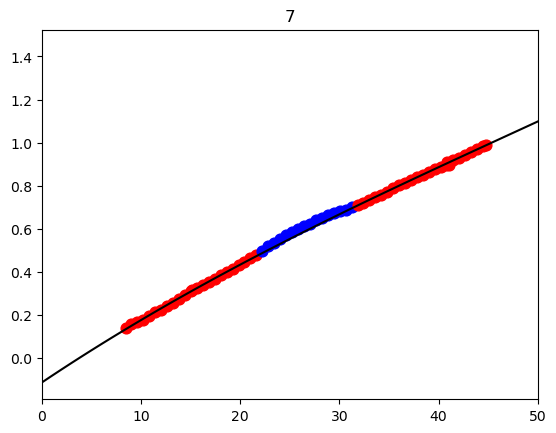

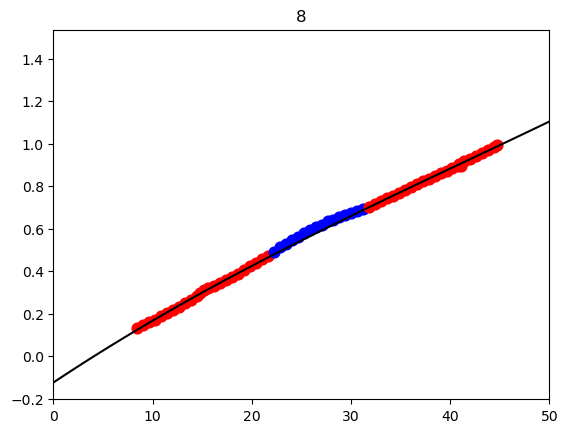

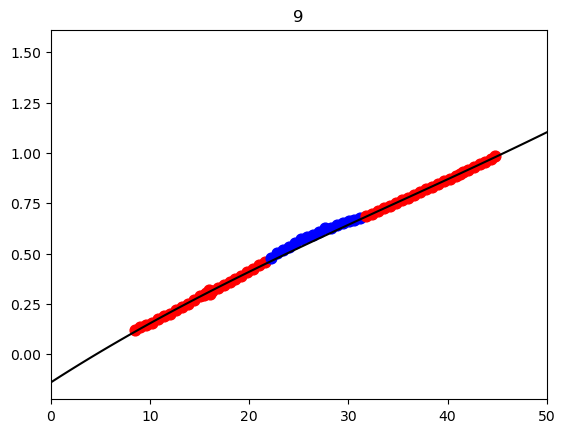

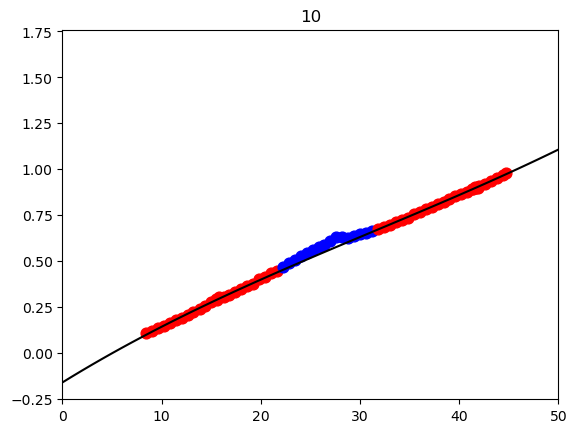

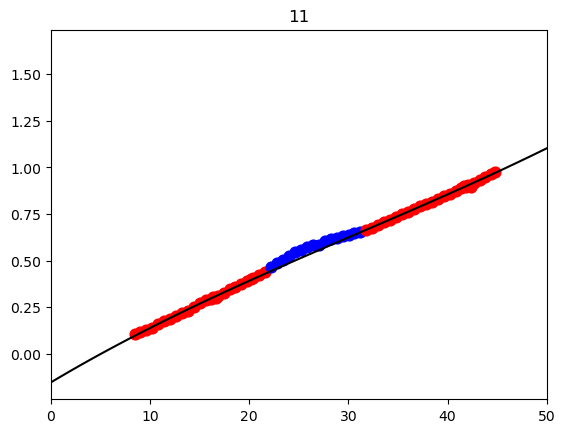

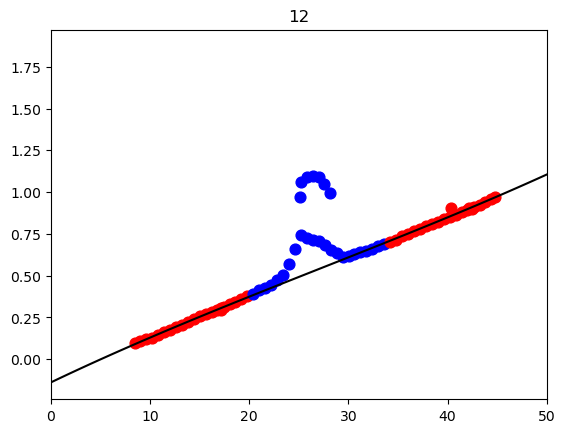

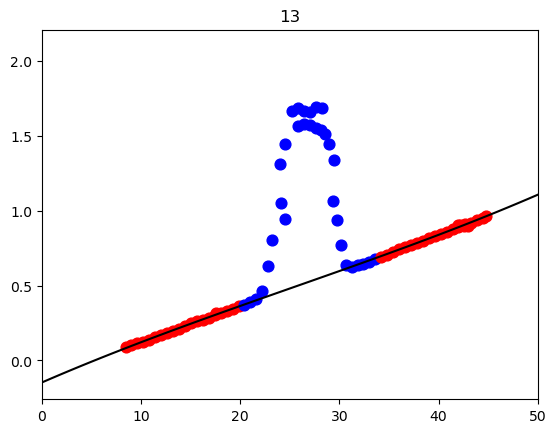

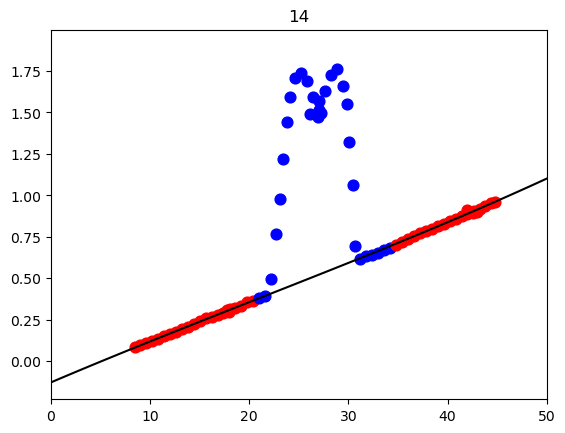

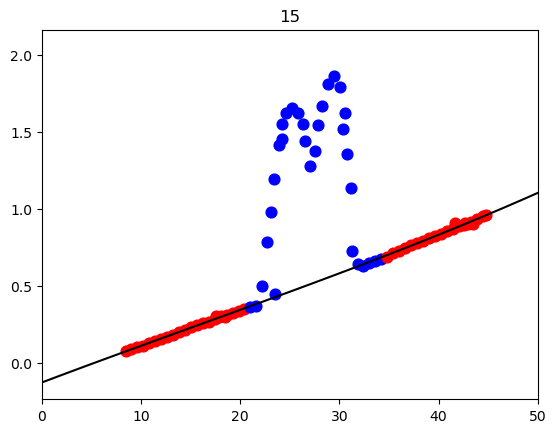

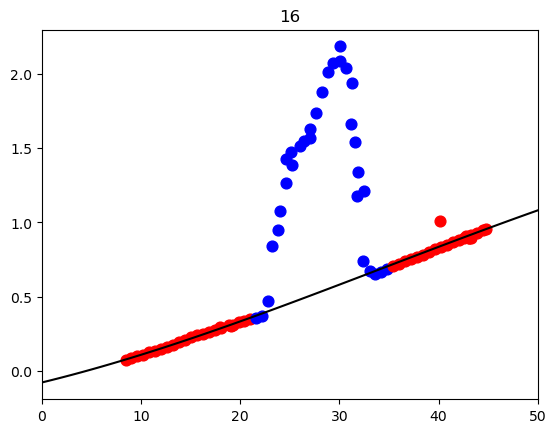

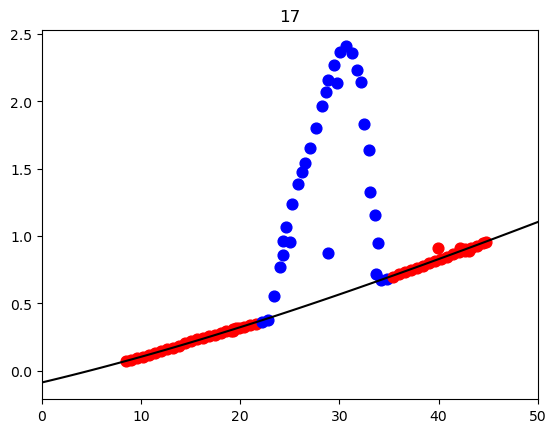

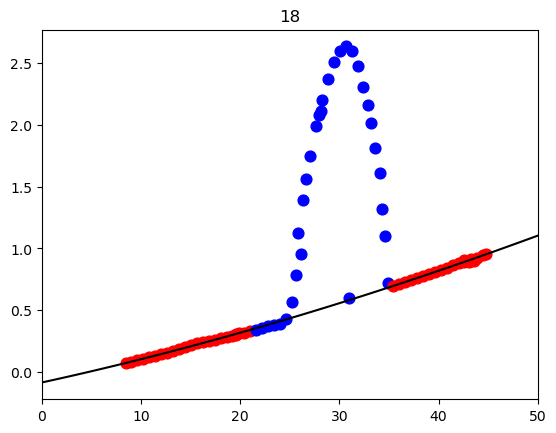

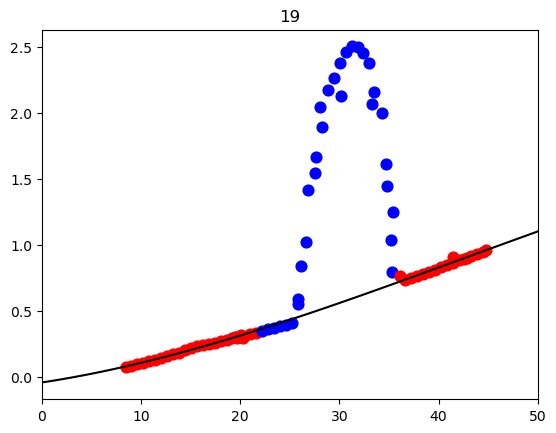

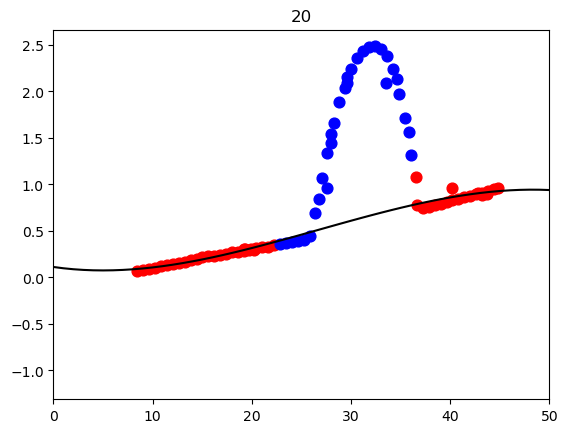

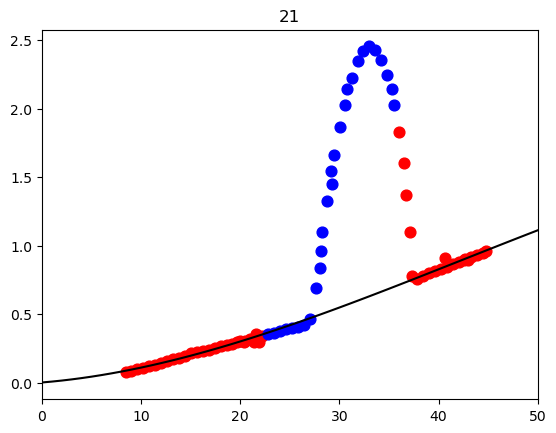

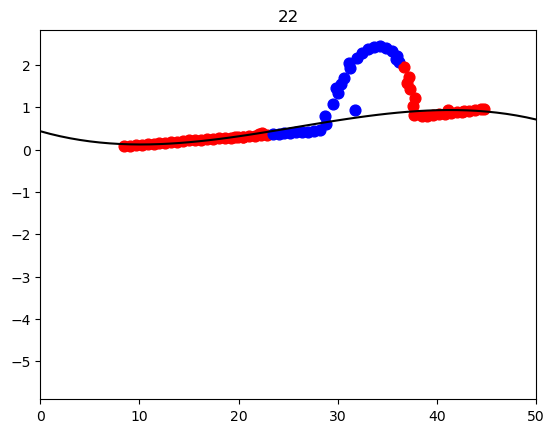

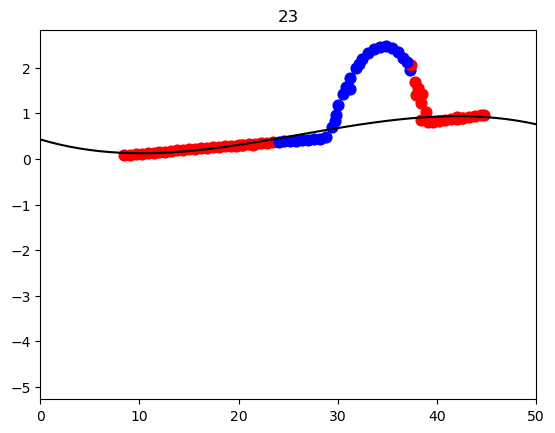

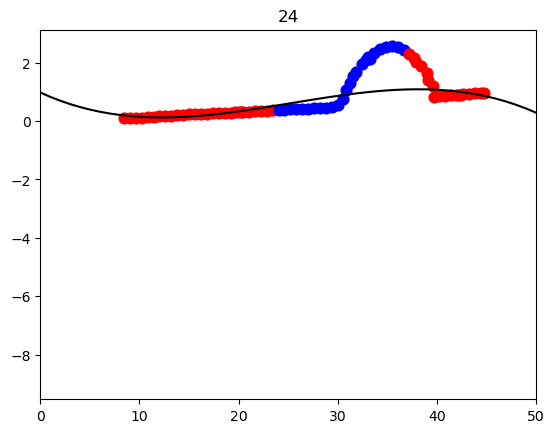

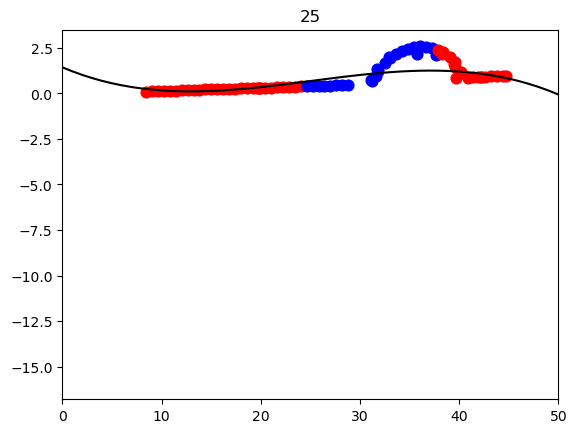

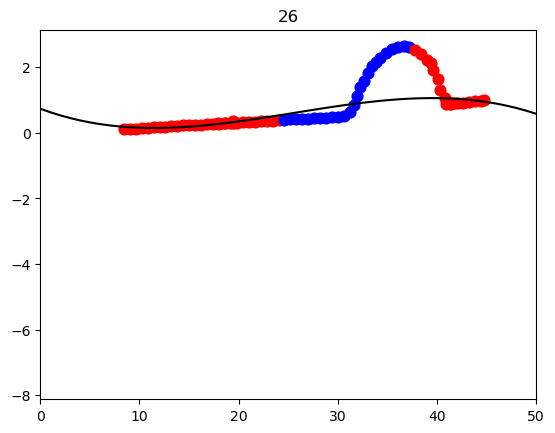

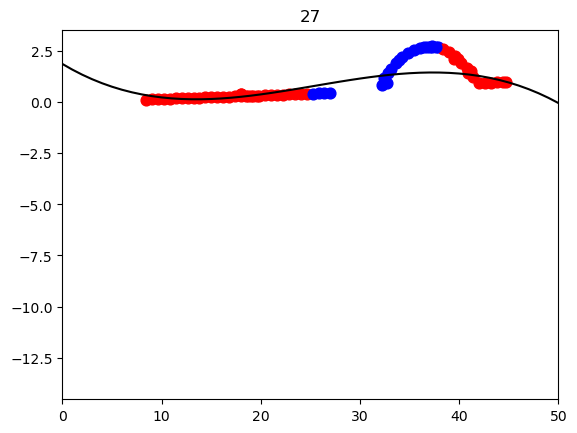

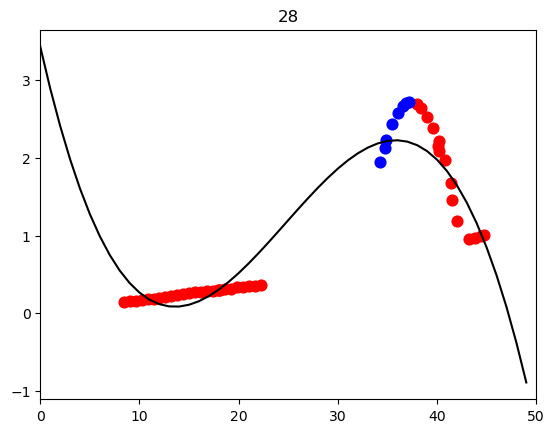

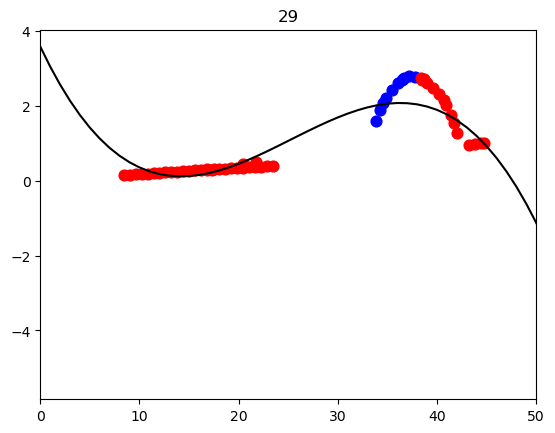

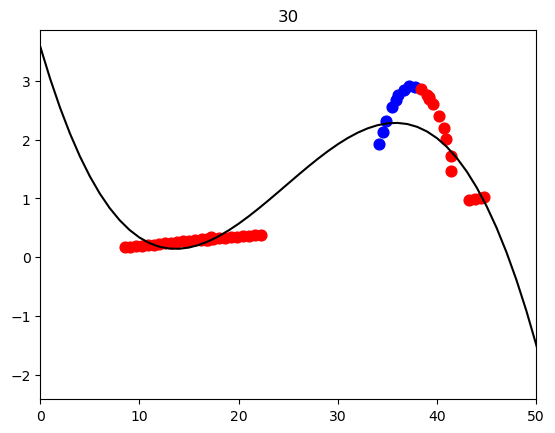

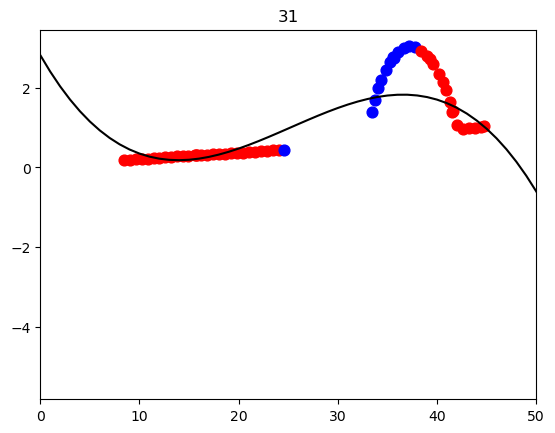

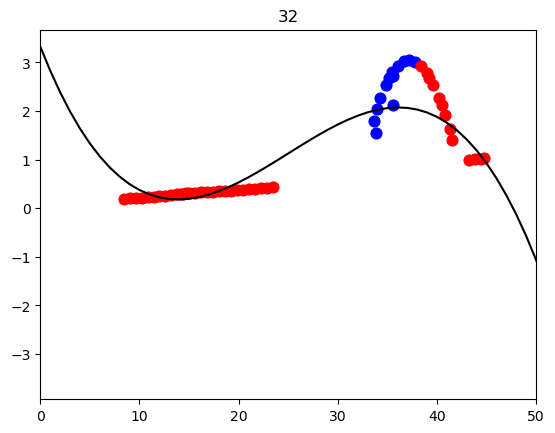

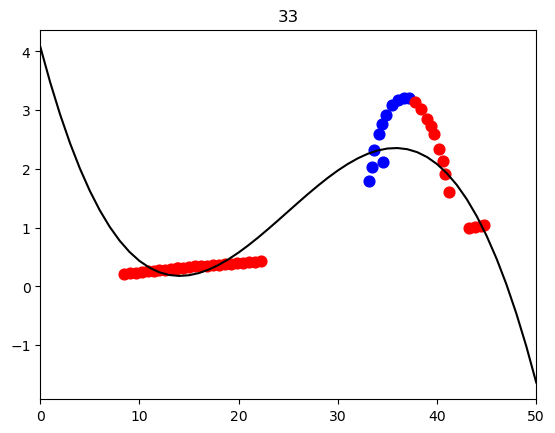

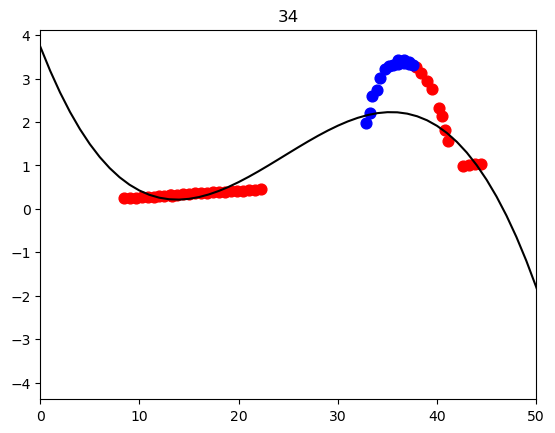

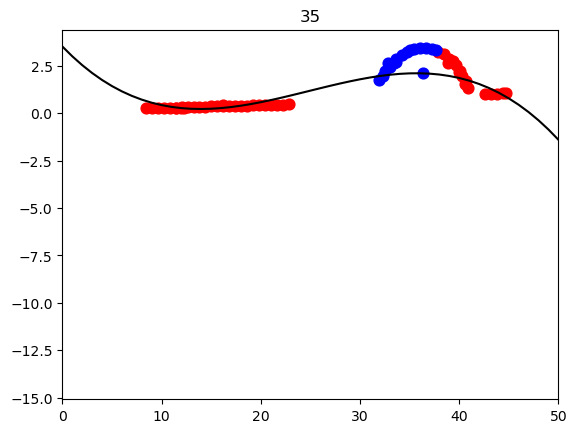

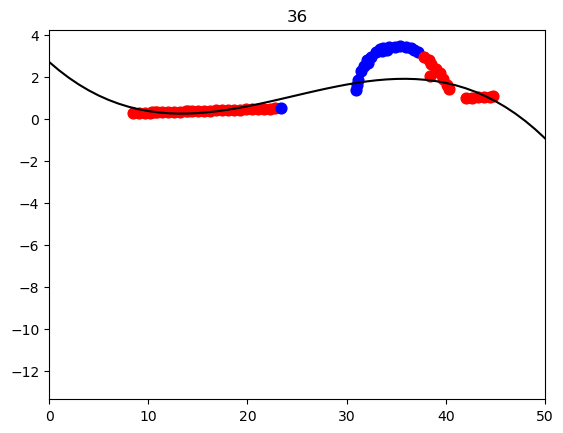

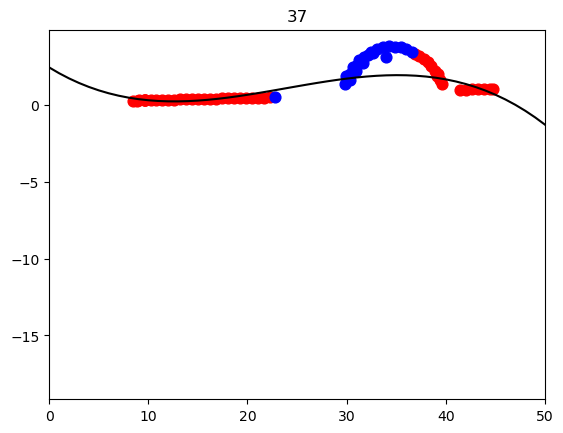

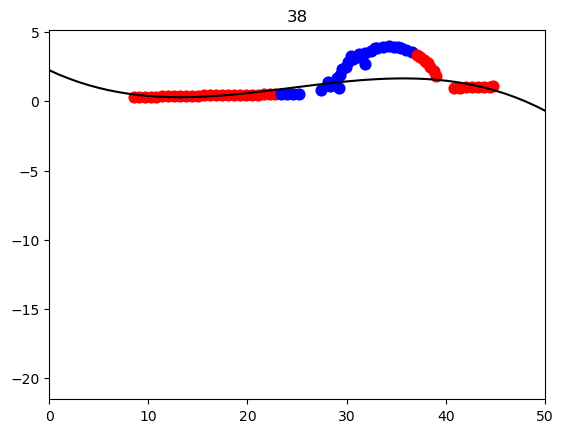

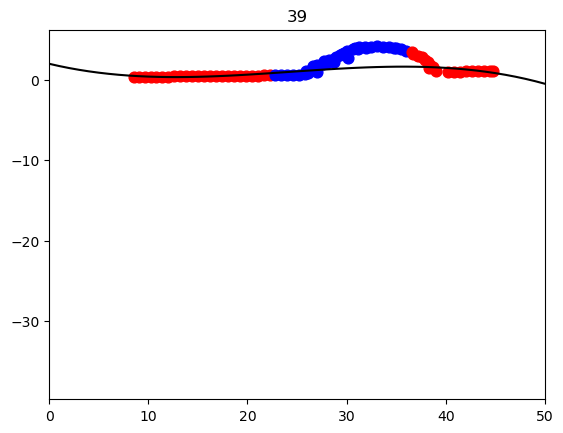

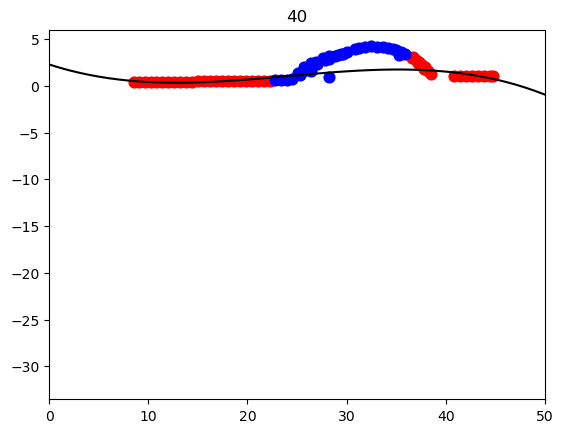

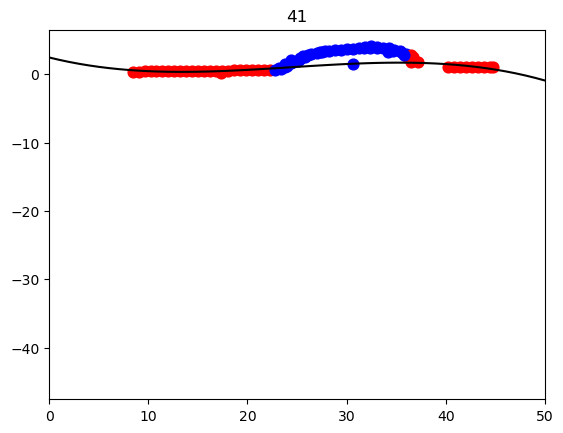

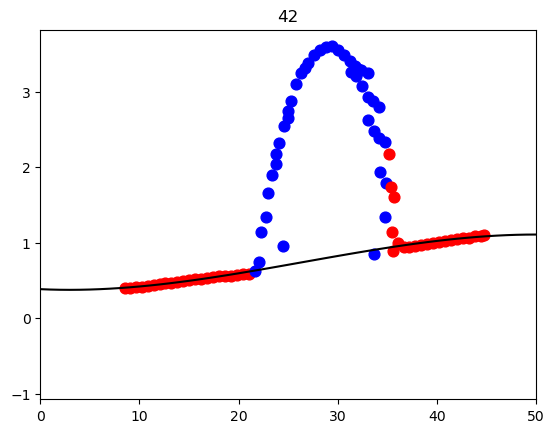

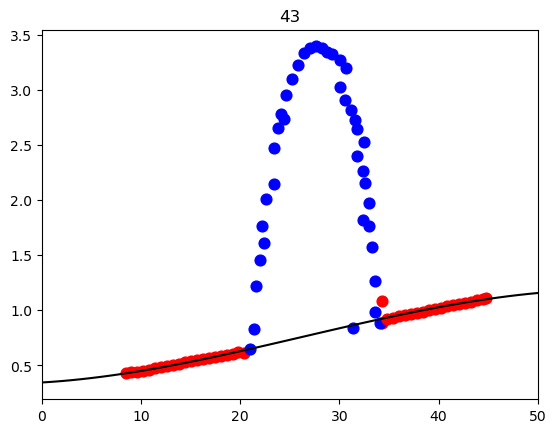

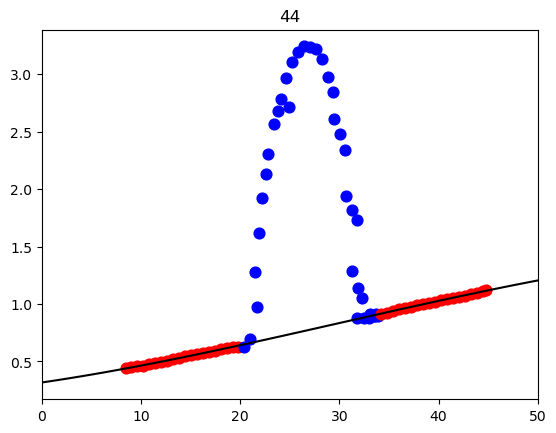

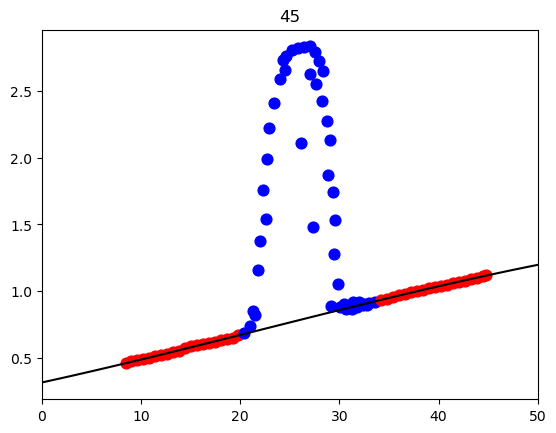

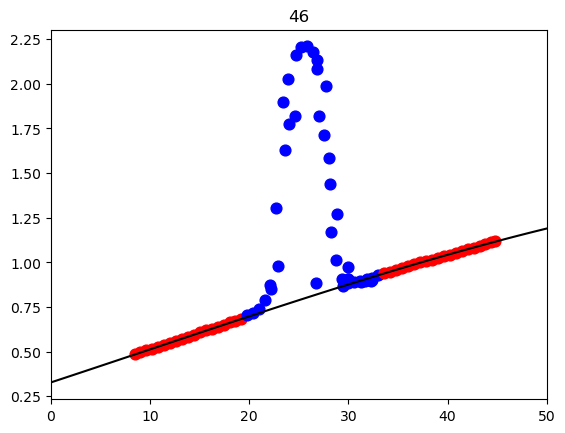

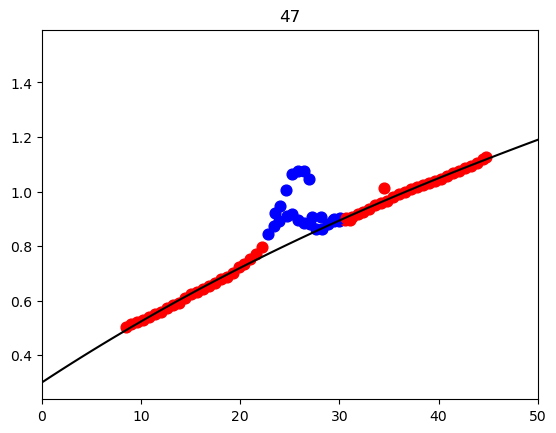

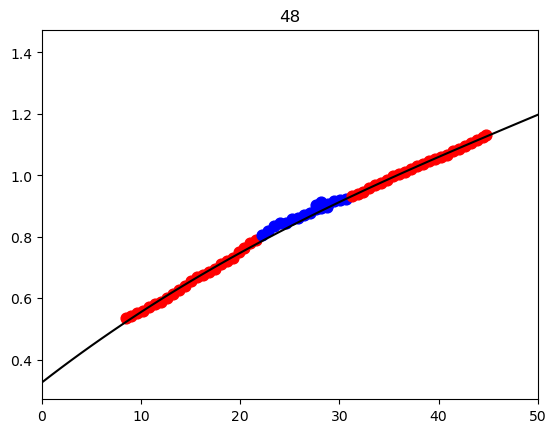

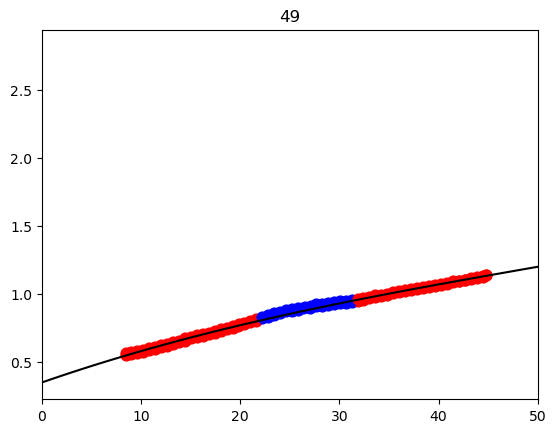

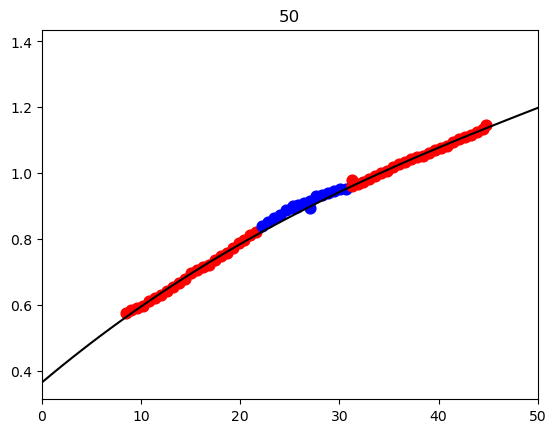

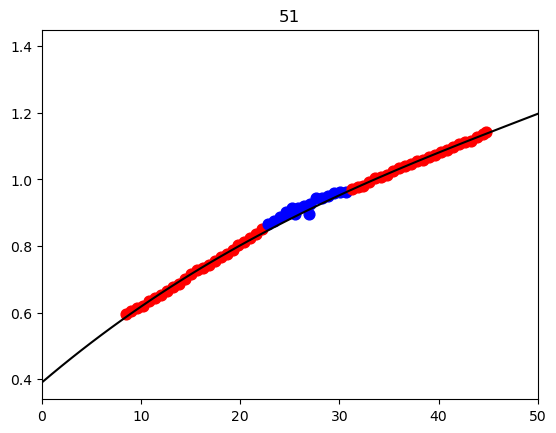

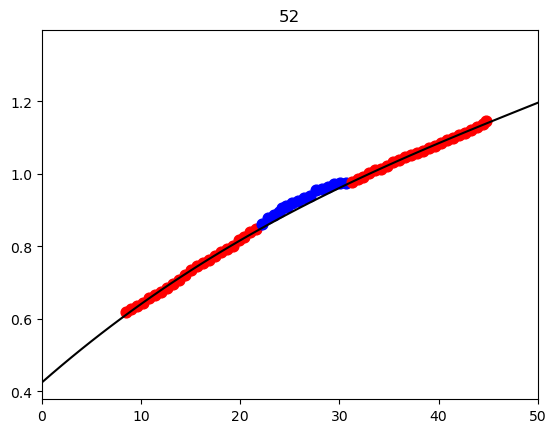

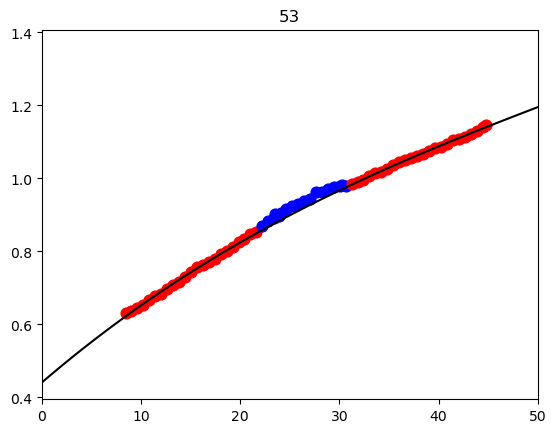

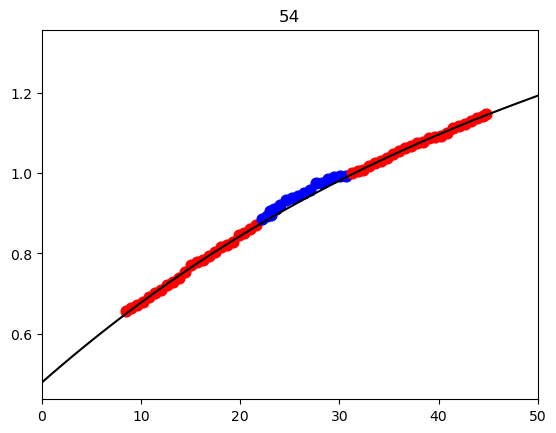

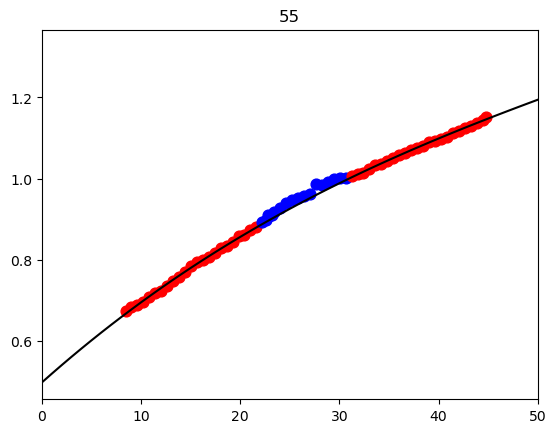

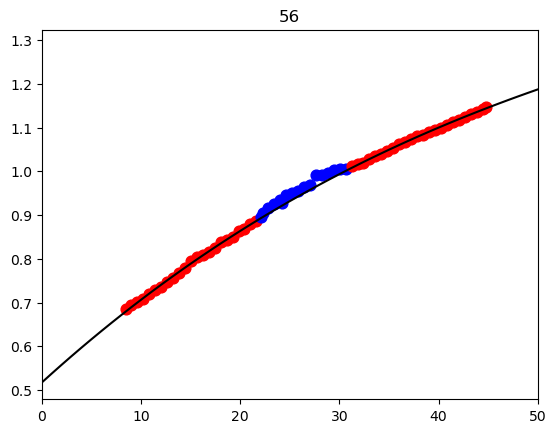

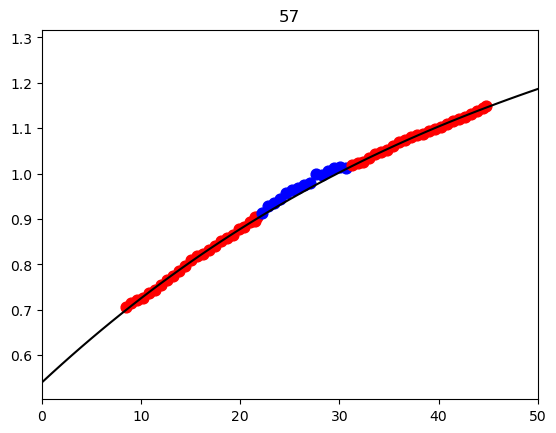

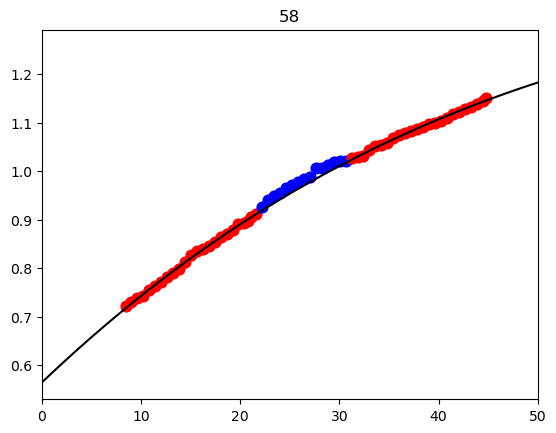

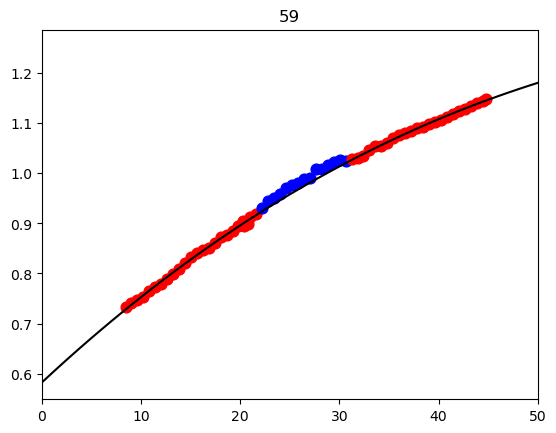

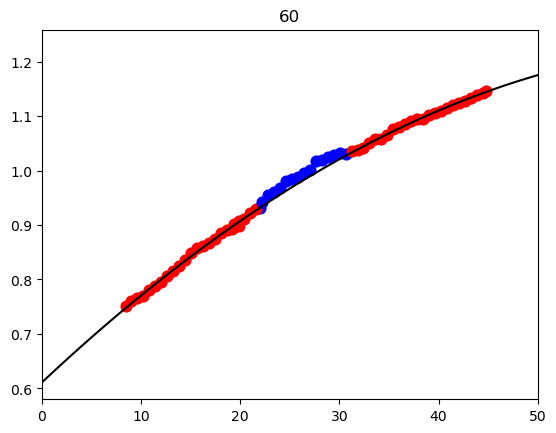

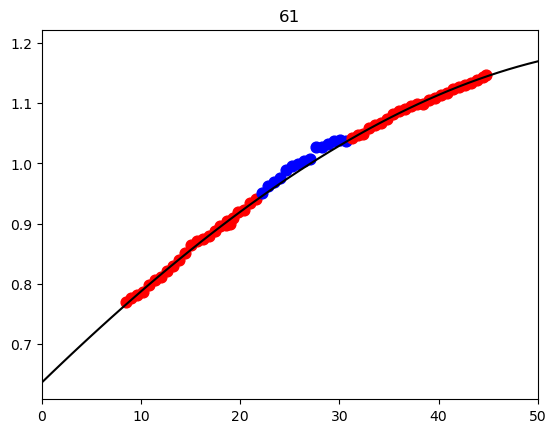

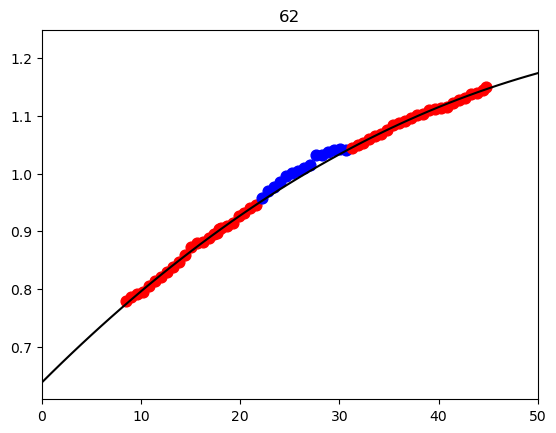

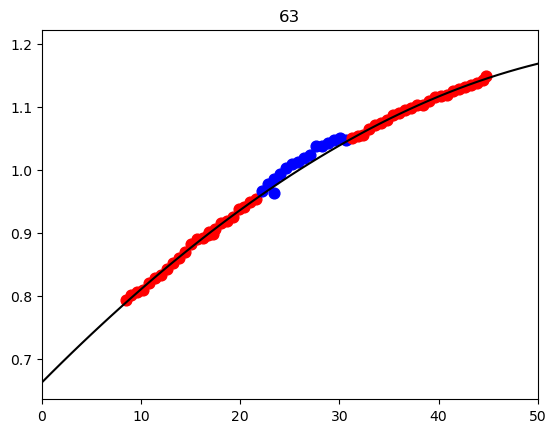

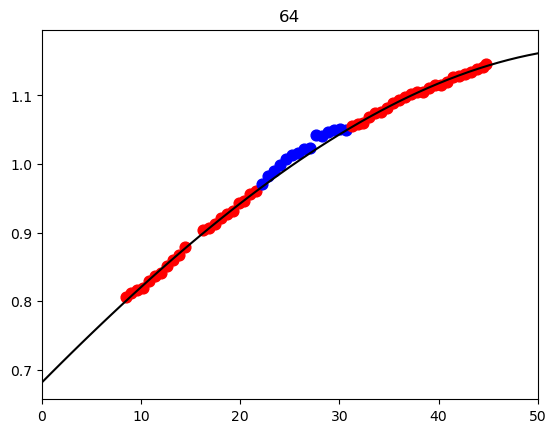

Data generation completed!


In [4]:
import os
import sys
from sklearn.cluster import KMeans
import warnings

for A in range(0, n_section + 1, 1):    
    line_start = A                 
    line_end = line_start + 0.6

    x_data = []              #x座標
    z_data = []              #z座標
    slope_data = []          #斜率
    dh_data = []             #每點高度差
    x_maxz_data = []         #每點到最高點的x向距離
    z_maxz_data = []         #每點到最高點的z向距離

    for i in range(len(y_f)-1):                 
        if y_f[i] > line_start and y_f[i] < line_end:
            x_data.append(x_f[i])
            z_data.append(z_f[i])
            
#     plt.scatter(x_data, z_data, s = 60, c = 'green', label = 'c0')
    for i in range(len(y_f)-1):  
        if y_f[i] > line_start and y_f[i] < line_end:
            slope_data.append((z_f[i+1]-z_f[i])/(x_f[i+1]-x_f[i]))
            dh_data.append(abs(z_f[i+1]-z_f[i]))
            
    if x_data != [] and len(x_data) >= 3: 
        class_data = {                  
                "x" : x_data,
                "h" : z_data,
                }
        class_data = pd.DataFrame(class_data)
        class_x = class_data.iloc[0:, 0:].values
        
        index = np.argmax(z_data)
        half = (max(x_data)-min(x_data))/2
        if 0 <= index - half <= 7:
            bias = 0
        elif 0 <= half - index <= 7:
            bias = 0 
        elif half - index > 7:
            bias = 10
        elif index - half > 7:
            bias = -10

        custom_centers = np.array([[np.min(x_data), np.min(z_data)], [x_data[index], np.max(z_data)], [np.max(x_data), np.min(z_data)]])
        
        warnings.filterwarnings("ignore", category=RuntimeWarning)
        kmeans = KMeans(n_clusters = 3, n_init=1, max_iter=1, init = custom_centers)
        y_kmeans = kmeans.fit_predict(class_x)
        
        class_weld_bead_x = []
        class_workpiece_x = []
        class_weld_bead_z = []
        class_workpiece_z = []
        kmeans_label = y_kmeans

        
        if max(class_x[y_kmeans == 0, 0]) > max(class_x[y_kmeans == 1, 0]) > max(class_x[y_kmeans == 2, 0]):
            class_weld_bead_x = class_x[y_kmeans == 1, 0]
            class_workpiece_x = np.concatenate((class_x[y_kmeans == 0, 0], class_x[y_kmeans == 2, 0]))
            class_weld_bead_z = class_x[y_kmeans == 1, 1]
            class_workpiece_z = np.concatenate((class_x[y_kmeans == 0, 1], class_x[y_kmeans == 2, 1]))
            kmeans_label[kmeans_label == 0] = 0
            kmeans_label[kmeans_label == 1] = 1
            kmeans_label[kmeans_label == 2] = 0

        elif max(class_x[y_kmeans == 0, 0]) > max(class_x[y_kmeans == 2, 0]) > max(class_x[y_kmeans == 1, 0]):
            class_weld_bead_x = class_x[y_kmeans == 2, 0]
            class_workpiece_x = np.concatenate((class_x[y_kmeans == 0, 0], class_x[y_kmeans == 1, 0]))
            class_weld_bead_z = class_x[y_kmeans == 2, 1]
            class_workpiece_z = np.concatenate((class_x[y_kmeans == 0, 1], class_x[y_kmeans == 1, 1]))
            kmeans_label[kmeans_label == 0] = 0
            kmeans_label[kmeans_label == 1] = 0
            kmeans_label[kmeans_label == 2] = 1

        elif max(class_x[y_kmeans == 1, 0]) > max(class_x[y_kmeans == 0, 0]) > max(class_x[y_kmeans == 2, 0]):
            class_weld_bead_x = class_x[y_kmeans == 0, 0]
            class_workpiece_x = np.concatenate((class_x[y_kmeans == 1, 0], class_x[y_kmeans == 2, 0]))
            class_weld_bead_z = class_x[y_kmeans == 0, 1]
            class_workpiece_z = np.concatenate((class_x[y_kmeans == 1, 1], class_x[y_kmeans == 2, 1])) 
            kmeans_label[kmeans_label == 0] = 1
            kmeans_label[kmeans_label == 1] = 0
            kmeans_label[kmeans_label == 2] = 0

        elif max(class_x[y_kmeans == 1, 0]) > max(class_x[y_kmeans == 2, 0]) > max(class_x[y_kmeans == 0, 0]):
            class_weld_bead_x = class_x[y_kmeans == 2, 0]
            class_workpiece_x = np.concatenate((class_x[y_kmeans == 0, 0], class_x[y_kmeans == 1, 0]))
            class_weld_bead_z = class_x[y_kmeans == 2, 1]
            class_workpiece_z = np.concatenate((class_x[y_kmeans == 0, 1], class_x[y_kmeans == 1, 1]))
            kmeans_label[kmeans_label == 0] = 0
            kmeans_label[kmeans_label == 1] = 0
            kmeans_label[kmeans_label == 2] = 1

        elif max(class_x[y_kmeans == 2, 0]) > max(class_x[y_kmeans == 0, 0]) > max(class_x[y_kmeans == 1, 0]):
            class_weld_bead_x = class_x[y_kmeans == 0, 0]
            class_workpiece_x = np.concatenate((class_x[y_kmeans == 1, 0], class_x[y_kmeans == 2, 0]))
            class_weld_bead_z = class_x[y_kmeans == 0, 1]
            class_workpiece_z = np.concatenate((class_x[y_kmeans == 1, 1], class_x[y_kmeans == 2, 1]))
            kmeans_label[kmeans_label == 0] = 1
            kmeans_label[kmeans_label == 1] = 0
            kmeans_label[kmeans_label == 2] = 0

        elif max(class_x[y_kmeans == 2, 0]) > max(class_x[y_kmeans == 1, 0]) > max(class_x[y_kmeans == 0, 0]):
            class_weld_bead_x = class_x[y_kmeans == 1, 0]
            class_workpiece_x = np.concatenate((class_x[y_kmeans == 0, 0], class_x[y_kmeans == 2, 0]))
            class_weld_bead_z = class_x[y_kmeans == 1, 1]
            class_workpiece_z = np.concatenate((class_x[y_kmeans == 0, 1], class_x[y_kmeans == 2, 1])) 
            kmeans_label[kmeans_label == 0] = 0
            kmeans_label[kmeans_label == 1] = 1
            kmeans_label[kmeans_label == 2] = 0

        params = np.polyfit(class_workpiece_x, class_workpiece_z, 3) #將工件(板材)形狀擬合成3次曲線
        funcs = np.poly1d(params)
 
        for i in range(len(class_workpiece_x) - 1, -1, -1):
            if np.abs(funcs(class_workpiece_x[i]) - class_workpiece_z[i]) >= 0.3:
                class_workpiece_x = np.delete(class_workpiece_x, i)
                class_workpiece_z = np.delete(class_workpiece_z, i)
        
        if len(class_workpiece_x) > 0 and len(class_workpiece_z) > 0:
            params2 = np.polyfit(class_workpiece_x, class_workpiece_z, 3) #將工件(板材)形狀擬合成3次曲線
            funcs_true1 = np.poly1d(params2)

            for i in range(len(class_workpiece_x) - 1, -1, -1):
                if np.abs(funcs_true1(class_workpiece_x[i]) - class_workpiece_z[i]) >= 0.3:
                    class_workpiece_x = np.delete(class_workpiece_x, i)
                    class_workpiece_z = np.delete(class_workpiece_z, i)

            if len(class_workpiece_x) > 0 and len(class_workpiece_z) > 0:
                params3 = np.polyfit(class_workpiece_x, class_workpiece_z, 3) #將工件(板材)形狀擬合成3次曲線
                funcs_true2 = np.poly1d(params3)
                globals()[f'funcs{A}'] = np.poly1d(params3)

            else:
                globals()[f'funcs{A}'] = np.poly1d(params2)
        
        else:
            globals()[f'funcs{A}'] = np.poly1d(params)
        
        for i in range(len(class_workpiece_x) - 1, -1, -1):
                class_workpiece_z[i] = np.abs(class_workpiece_z[i] - globals()[f'funcs{A}'](class_workpiece_x[i]))

        warnings.simplefilter('ignore', np.RankWarning)

        # globals()[f'funcs{A}'] = np.poly1d(params3)
        
        for i in range(len(z_data) - 1, -1, -1):
            if globals()[f'funcs{A}'](x_data[i]) - z_data[i] >= 0.5:
                x_data = np.delete(x_data, i)
                z_data = np.delete(z_data, i)
                slope_data = np.delete(slope_data, i)
                dh_data = np.delete(dh_data, i)
                kmeans_label = np.delete(kmeans_label, i)
        
        globals()[f'z_fix{A}'] = np.around(z_data[i], decimals=1)              

        for i in range(len(kmeans_label)):
            if kmeans_label[i]==0:
                plt.scatter(x_data[i], z_data[i], s = 60, c = 'red', label = 'c0')
            elif kmeans_label[i]==1:
                plt.scatter(x_data[i], z_data[i], s = 60, c = 'blue', label = 'c0')
        label_test = []
        for i in range(len(kmeans_label)):
            if kmeans_label[i] == 0:
                z_data[i] = np.abs(z_data[i] - globals()[f'funcs{A}'](x_data[i]))
                # z_data[i] = np.abs(z_data[i] - np.around(z_data[i], decimals=1))
                if z_data[i] < 0.1:
                    label_test.append(0)
                else:
                    label_test.append(1)

            elif kmeans_label[i] == 1:
                z_data[i] = np.abs(z_data[i] - globals()[f'funcs{A}'](x_data[i]))
                if z_data[i] < 0.1:
                    label_test.append(0)
                else:
                    label_test.append(1)

        z_max = np.argmax(z_data)
        x_at_zmax = x_data[z_max]
        z_at_zmax = z_data[z_max]
        for i in range(len(x_data)):
            x_maxz_data.append(abs(x_data[i]-x_at_zmax))
            z_maxz_data.append(abs(z_at_zmax-z_data[i]))

        data_dict = {                  
            "x" : x_data,
            "x to zmax" : x_maxz_data,
            "Slope" : slope_data,
            "z to zmax" : z_maxz_data,
            "dh" : dh_data,
            "h" : z_data,
            "Label" : label_test
        }
        globals()[f'data_set{A}'] = pd.DataFrame(data_dict)
        plt.title(A)
        plt.xlim(0, 50)
        plt.plot(range(0, len(x_data)+1, 1), globals()[f'funcs{A}'](range(0, len(x_data)+1, 1)), c = 'black')
        plt.show()

    else:
        continue
        
print('Data generation completed!')

In [5]:
# from sklearn.model_selection import GridSearchCV
# parameters = [
#     {'n_estimators': range(1, 200, 10), 'criterion': ['entropy'], 'min_samples_split': range(1, 100, 5)}
#      ] #'max_features': range(5, 50, 2), 'max_depth': range(1, 20, 1)
# grid_search = GridSearchCV(estimator = classifier, 
#                           param_grid = parameters,
#                           scoring = 'accuracy',
#                           cv = 10,
#                           n_jobs = -1)
# grid_search = grid_search.fit(X_train, y_train)
# best_accuracy = grid_search.best_score_
# best_parameters = grid_search.best_params_
# print('///////////////////////')
# print(best_accuracy)
# print(best_parameters)
# print('///////////////////////')

# 隨機森林訓練

In [6]:
data_set = pd.read_csv('D:/jy_files/curve_fit/0419_2_test/final_0419_2_test_data_set.csv')
data_set = data_set.astype(np.float64)
data_set = data_set.dropna()
#C:/Users/mmdl/Desktop/jy_files/curve_fit/fit_final_new_data_set.csv #D:/USER/Desktop/files/curve_fit/fit_final_new_data_set.csv
#C:/Users/mmdl/Desktop/jy_files/curve_fit/0419_2     #D:/USER/Desktop/files/curve_fit/final_0419_2_data_set.csv
X_train_data = data_set.iloc[0:, 2:7].values
y_train_data = data_set.iloc[0:, 7].values

X_train, X_test, y_train, y_test = train_test_split(X_train_data, y_train_data, test_size = 0.2, random_state = 0)

# from sklearn.preprocessing import StandardScaler

# sc = StandardScaler()
# X_train = sc.fit_transform(X_train)
# X_test = sc.transform(X_test)


from sklearn.ensemble import RandomForestClassifier
classifier = RandomForestClassifier(n_estimators = 31, max_depth = 3)
classifier.fit(X_train, y_train)

y_pred = classifier.predict(X_test)

#X_test = sc.inverse_transform(X_test) #反正規化

from sklearn.metrics import confusion_matrix                                #混淆矩陣
cm = confusion_matrix(y_test, y_pred)
print('Confusion matrix is:')
print(cm)
print('---------------------------------------------------------------------')

from sklearn.model_selection import cross_val_score                         #交叉驗證
cv = 5
accuracies = cross_val_score(estimator = classifier, X = X_test, y = y_pred, cv = 5)
accuracies.mean()
accuracies.std()
print('Cross-validation: ' + str(cv) + '-fold')
print('Mean accuracy is: ' + str(accuracies.mean()))
print('---------------------------------------------------------------------')
        
from sklearn.metrics import accuracy_score

acc_test = accuracy_score(y_test, y_pred)
print('Model accuracy is: ' + str(acc_test))

Confusion matrix is:
[[1723   13]
 [  29  676]]
---------------------------------------------------------------------
Cross-validation: 5-fold
Mean accuracy is: 0.9885329712695701
---------------------------------------------------------------------
Model accuracy is: 0.9827939369111021


# 銲道分類

Data found successfully: data_set0


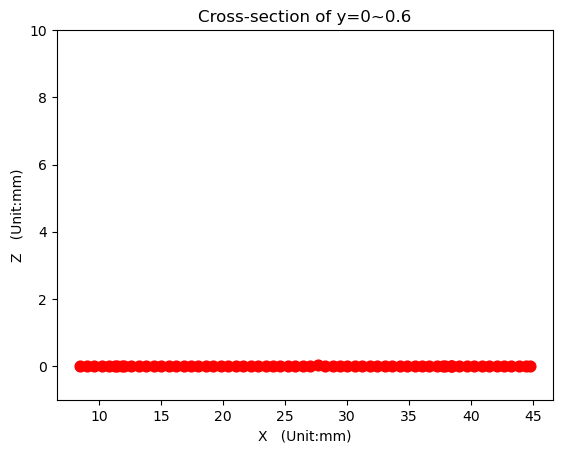

Accuracy is: 1.0
The maximum height is: 0.020074209872639304
No weld bead detected
---------------------------------------------------------------------
Data found successfully: data_set1


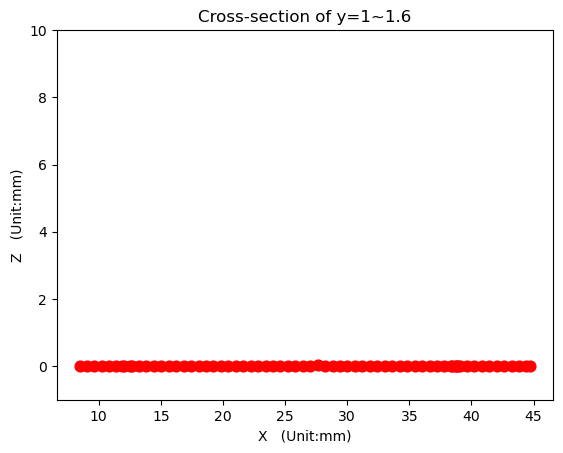

Accuracy is: 1.0
The maximum height is: 0.020007746469969834
No weld bead detected
---------------------------------------------------------------------
Data found successfully: data_set2


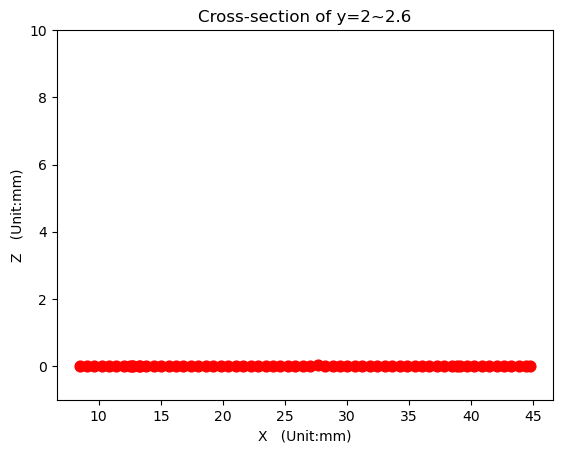

Accuracy is: 1.0
The maximum height is: 0.020020135503468484
No weld bead detected
---------------------------------------------------------------------
Data found successfully: data_set3


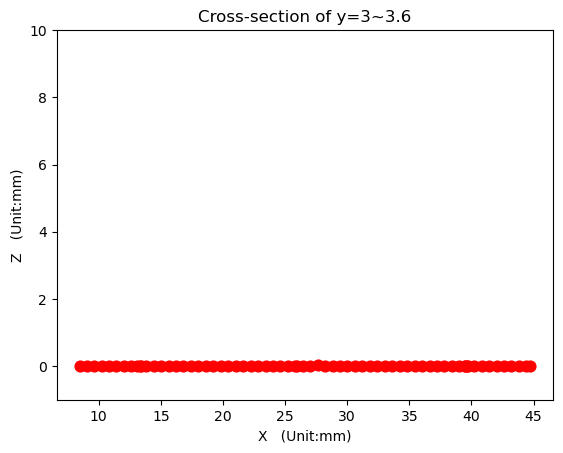

Accuracy is: 1.0
The maximum height is: 0.02202005250914485
No weld bead detected
---------------------------------------------------------------------
Data found successfully: data_set4


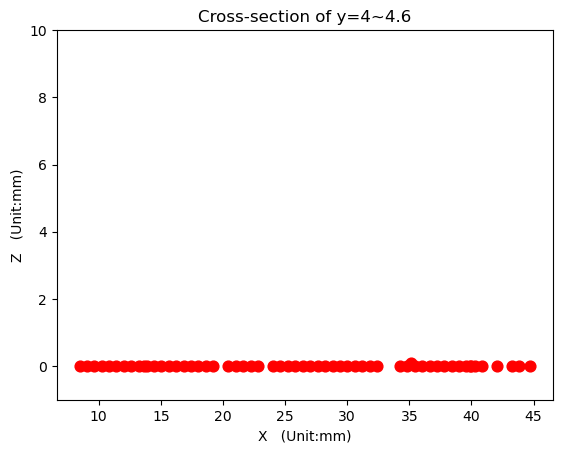

Accuracy is: 1.0
The maximum height is: 0.09139865360886268
No weld bead detected
---------------------------------------------------------------------
Data found successfully: data_set5


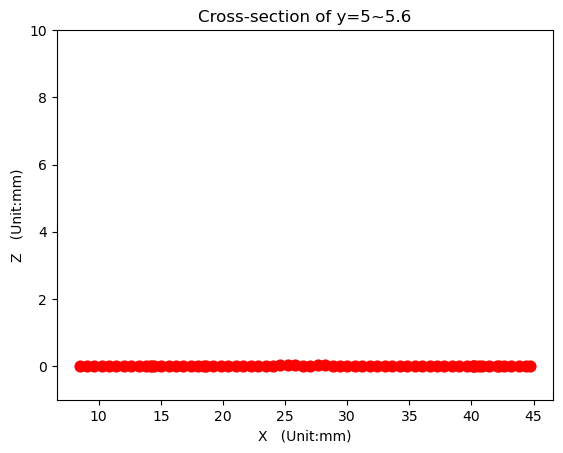

Accuracy is: 1.0
The maximum height is: 0.02543025362231277
No weld bead detected
---------------------------------------------------------------------
Data found successfully: data_set6


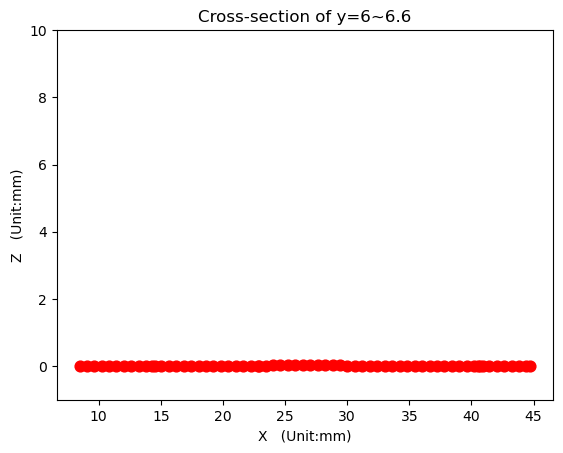

Accuracy is: 1.0
The maximum height is: 0.029377790649044777
No weld bead detected
---------------------------------------------------------------------
Data found successfully: data_set7


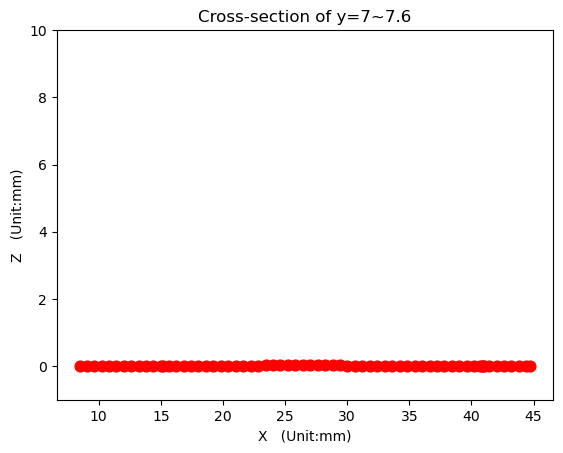

Accuracy is: 1.0
The maximum height is: 0.029155847639437682
No weld bead detected
---------------------------------------------------------------------
Data found successfully: data_set8


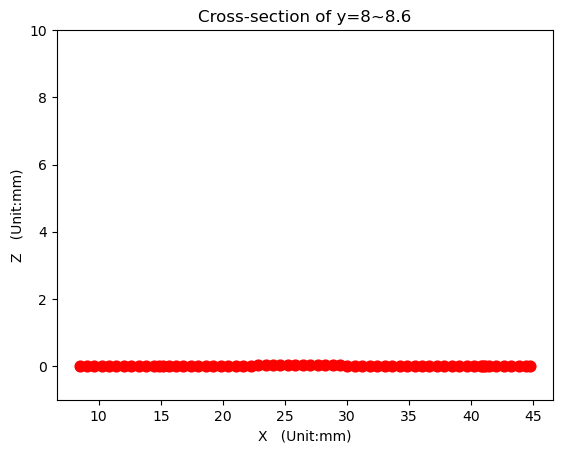

Accuracy is: 1.0
The maximum height is: 0.03101299133654567
No weld bead detected
---------------------------------------------------------------------
Data found successfully: data_set9


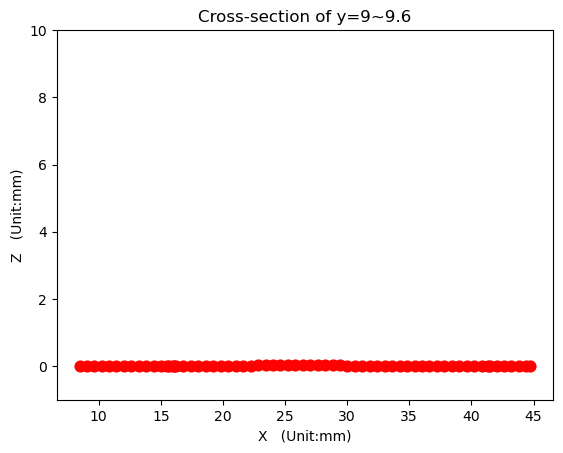

Accuracy is: 1.0
The maximum height is: 0.037273083626769066
No weld bead detected
---------------------------------------------------------------------
Data found successfully: data_set10


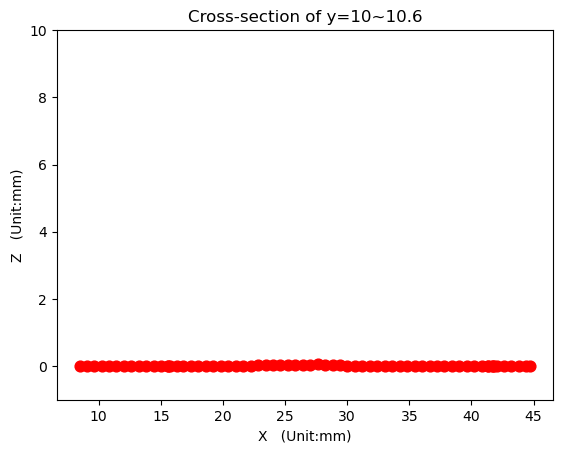

Accuracy is: 1.0
The maximum height is: 0.053516848279319906
No weld bead detected
---------------------------------------------------------------------
Data found successfully: data_set11


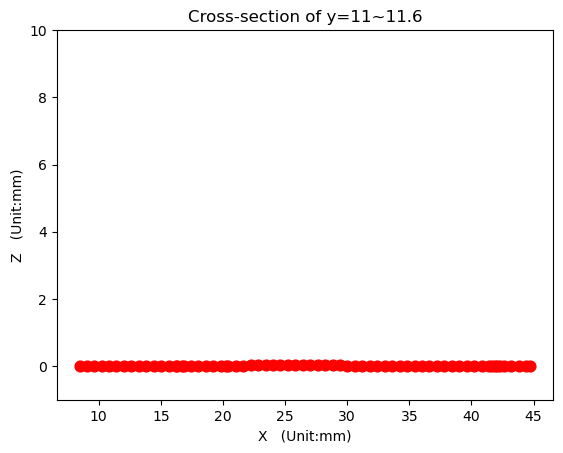

Accuracy is: 1.0
The maximum height is: 0.045444120220482054
No weld bead detected
---------------------------------------------------------------------
Data found successfully: data_set12


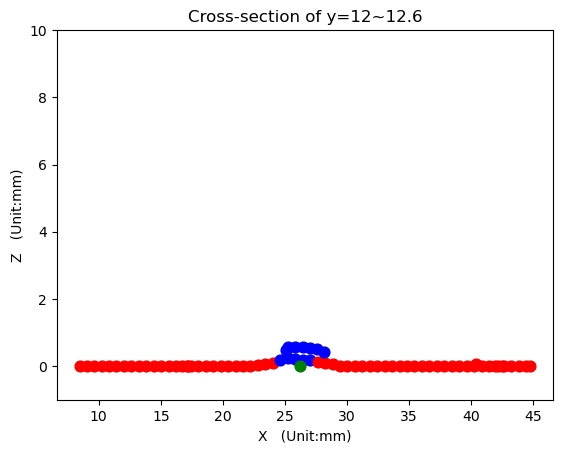

Accuracy is: 0.972972972972973
Center point of weld bead is: 26.19740916970495
Total height of weld bead is: 0.40861459153183777
---------------------------------------------------------------------
Data found successfully: data_set13


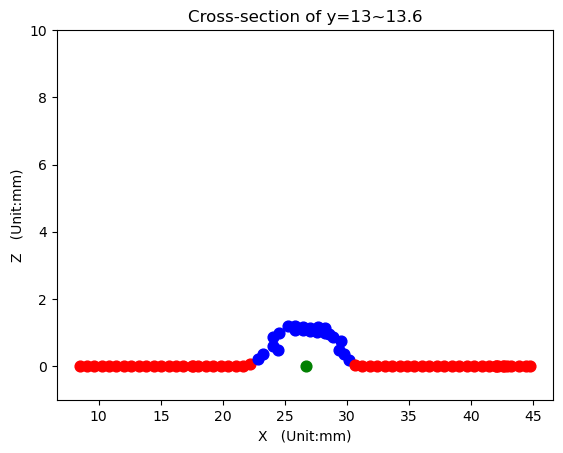

Accuracy is: 1.0
Center point of weld bead is: 26.722195378612675
Total height of weld bead is: 1.0193339583380638
---------------------------------------------------------------------
Data found successfully: data_set14


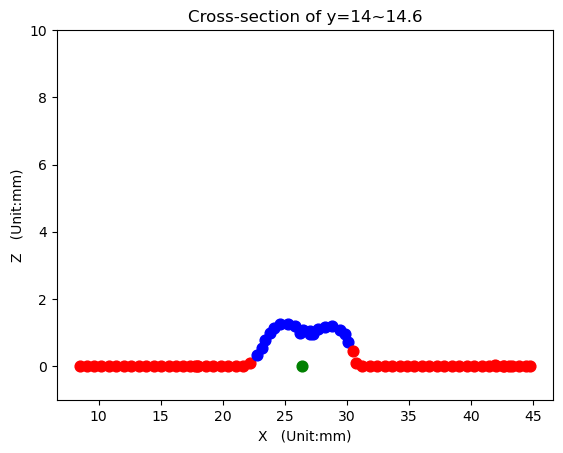

Accuracy is: 0.9866666666666667
Center point of weld bead is: 26.389121037948854
Total height of weld bead is: 0.9157484316148417
---------------------------------------------------------------------
Data found successfully: data_set15


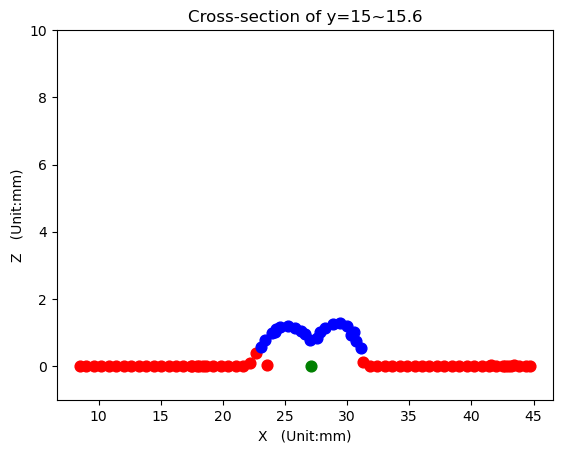

Accuracy is: 0.9615384615384616
Center point of weld bead is: 27.099200286251474
Total height of weld bead is: 0.7687321739225556
---------------------------------------------------------------------
Data found successfully: data_set16


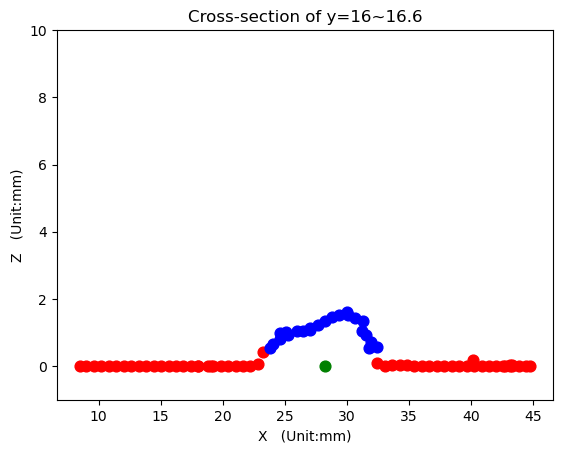

Accuracy is: 0.9743589743589743
Center point of weld bead is: 28.19733427314751
Total height of weld bead is: 1.080530150113189
---------------------------------------------------------------------
Data found successfully: data_set17


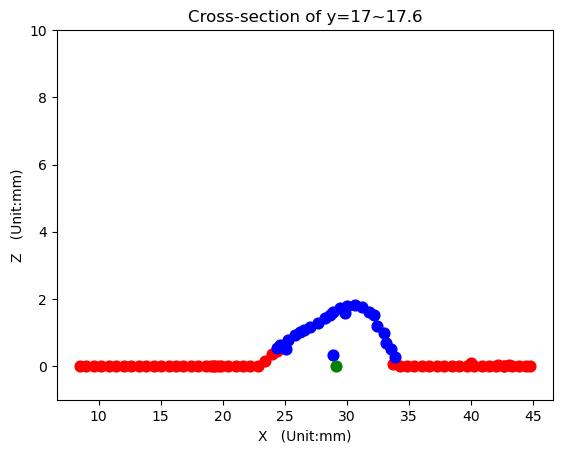

Accuracy is: 0.9625
Center point of weld bead is: 29.119439323458487
Total height of weld bead is: 1.5435134841939897
---------------------------------------------------------------------
Data found successfully: data_set18


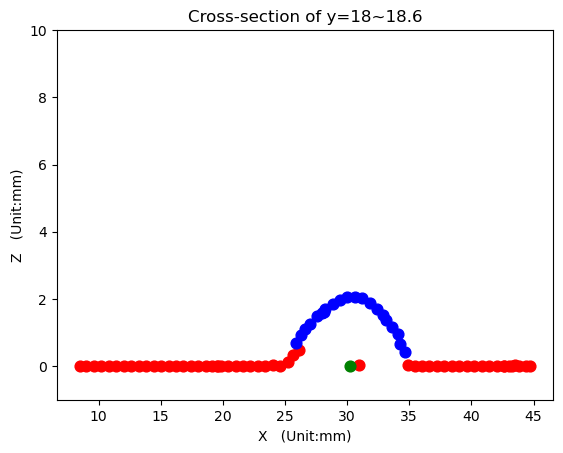

Accuracy is: 0.9605263157894737
Center point of weld bead is: 30.227633405926024
Total height of weld bead is: 1.642990607385077
---------------------------------------------------------------------
Data found successfully: data_set19


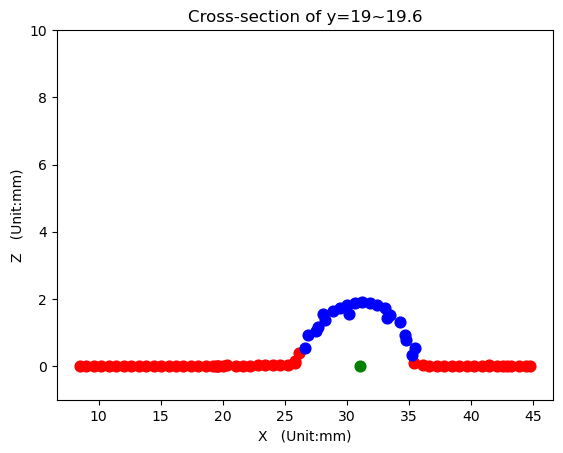

Accuracy is: 0.9736842105263158
Center point of weld bead is: 31.074687968871455
Total height of weld bead is: 1.5734823082816134
---------------------------------------------------------------------
Data found successfully: data_set20


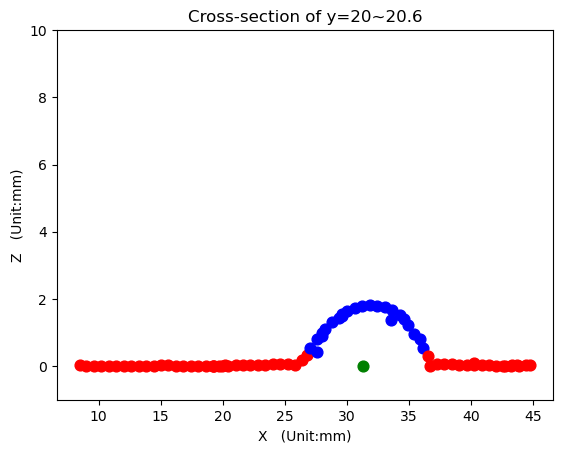

Accuracy is: 0.95
Center point of weld bead is: 31.295053203331978
Total height of weld bead is: 1.3941762412522645
---------------------------------------------------------------------
Data found successfully: data_set21


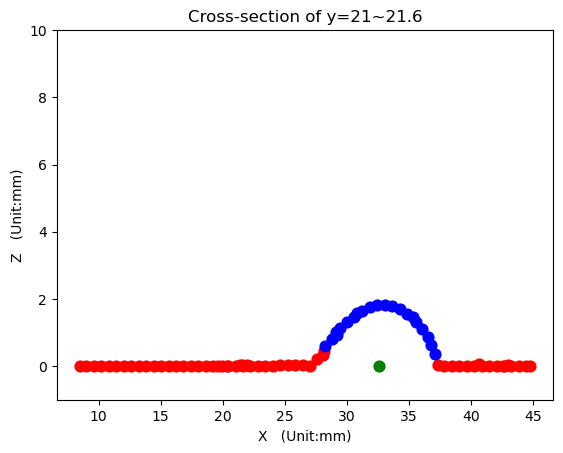

Accuracy is: 0.9615384615384616
Center point of weld bead is: 32.59386845293423
Total height of weld bead is: 1.4661016831594893
---------------------------------------------------------------------
Data found successfully: data_set22


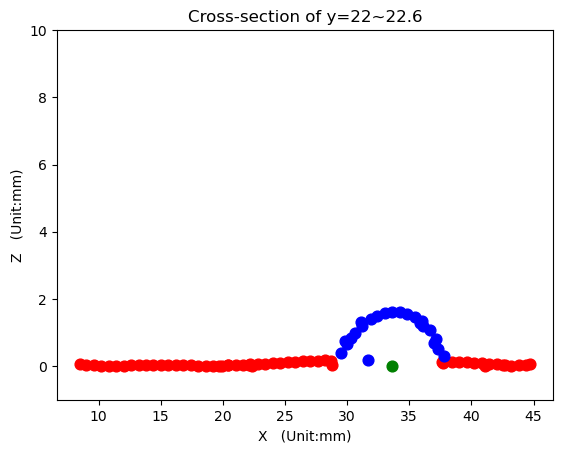

Accuracy is: 0.8481012658227848
Center point of weld bead is: 33.63924407931642
Total height of weld bead is: 1.4409051089512022
---------------------------------------------------------------------
Data found successfully: data_set23


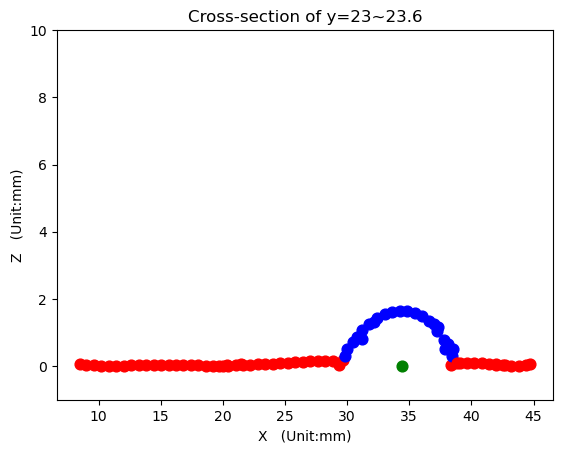

Accuracy is: 0.8607594936708861
Center point of weld bead is: 34.41521840206361
Total height of weld bead is: 1.351873386104673
---------------------------------------------------------------------
Data found successfully: data_set24


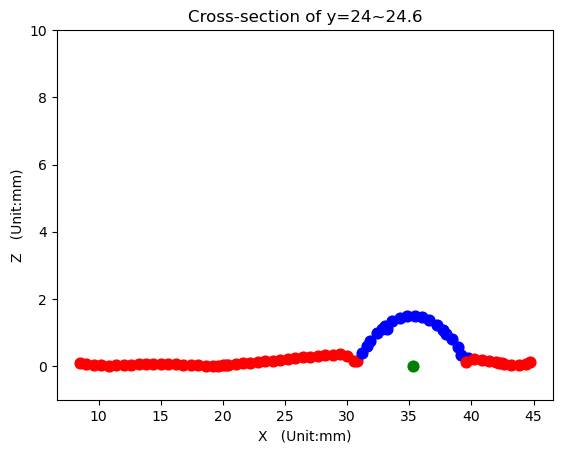

Accuracy is: 0.6986301369863014
Center point of weld bead is: 35.296970695404
Total height of weld bead is: 1.252633762599886
---------------------------------------------------------------------
Data found successfully: data_set25


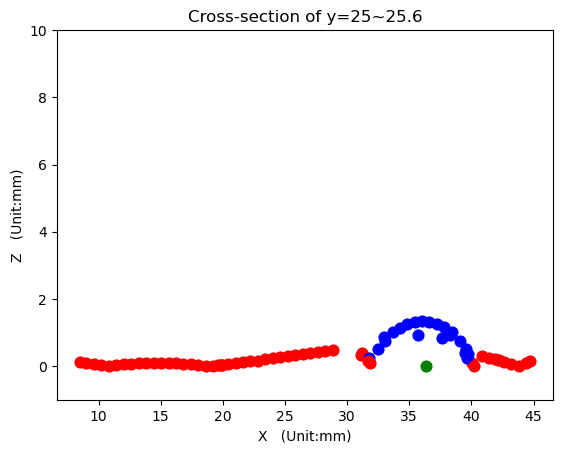

Accuracy is: 0.6533333333333333
Center point of weld bead is: 36.36185268808168
Total height of weld bead is: 1.097082888527309
---------------------------------------------------------------------
Data found successfully: data_set26


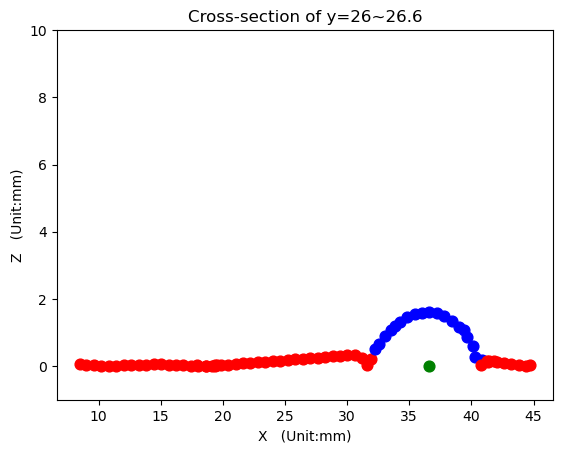

Accuracy is: 0.7105263157894737
Center point of weld bead is: 36.58370905622266
Total height of weld bead is: 1.428705252992188
---------------------------------------------------------------------
Data found successfully: data_set27


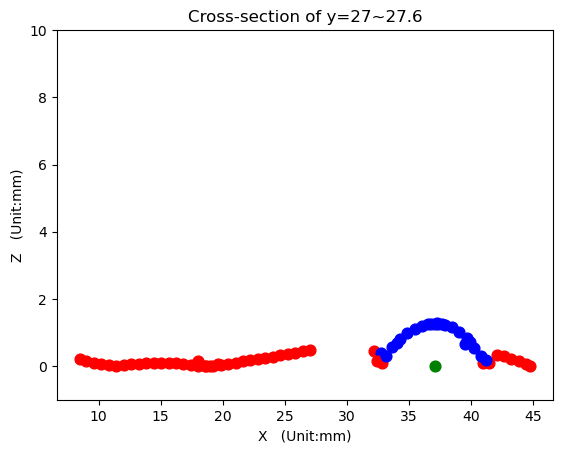

Accuracy is: 0.676056338028169
Center point of weld bead is: 37.084546845609495
Total height of weld bead is: 1.082101648546433
---------------------------------------------------------------------
Data found successfully: data_set28


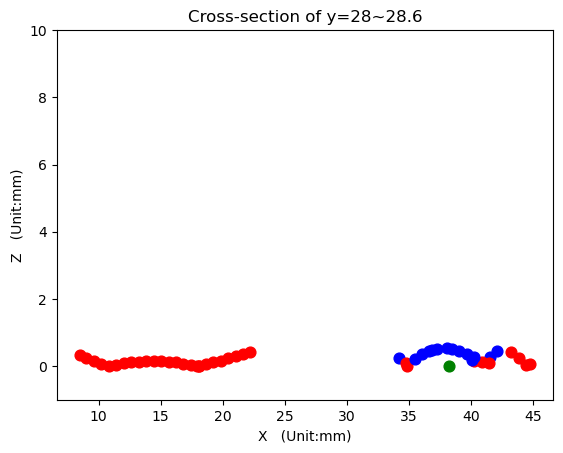

Accuracy is: 0.5918367346938775
Center point of weld bead is: 38.23146613695042
Total height of weld bead is: 0.3417578628168767
---------------------------------------------------------------------
Data found successfully: data_set29


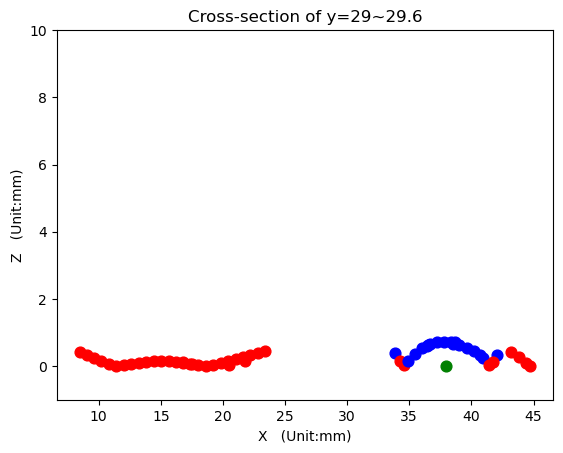

Accuracy is: 0.5892857142857143
Center point of weld bead is: 37.93955350716356
Total height of weld bead is: 0.5642913811665977
---------------------------------------------------------------------
Data found successfully: data_set30


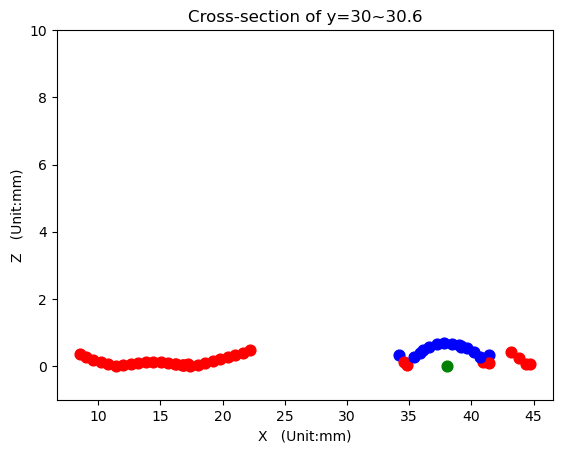

Accuracy is: 0.6274509803921569
Center point of weld bead is: 38.06780321350029
Total height of weld bead is: 0.4075462692381546
---------------------------------------------------------------------
Data found successfully: data_set31


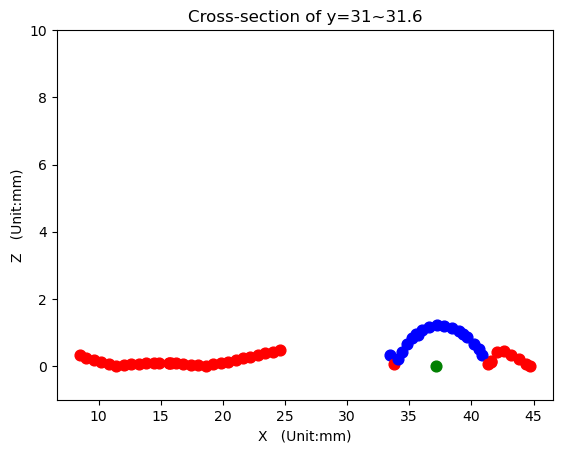

Accuracy is: 0.6206896551724138
Center point of weld bead is: 37.16680975637914
Total height of weld bead is: 0.9896513354924266
---------------------------------------------------------------------
Data found successfully: data_set32


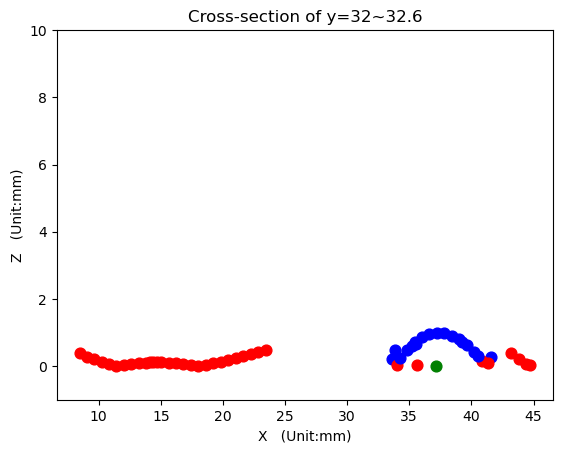

Accuracy is: 0.6296296296296297
Center point of weld bead is: 37.16205160936781
Total height of weld bead is: 0.7829712068577659
---------------------------------------------------------------------
Data found successfully: data_set33


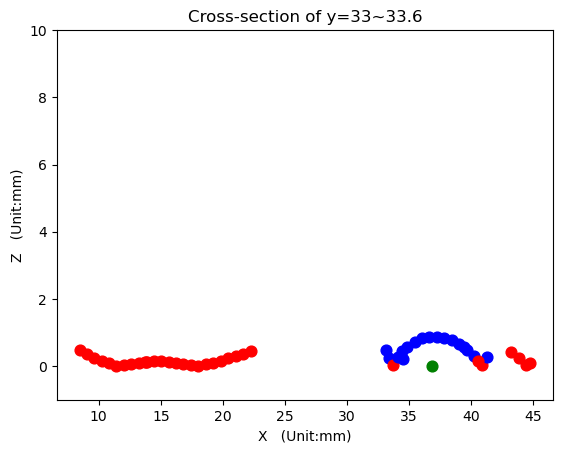

Accuracy is: 0.58
Center point of weld bead is: 36.79491105656727
Total height of weld bead is: 0.6559169861020497
---------------------------------------------------------------------
Data found successfully: data_set34


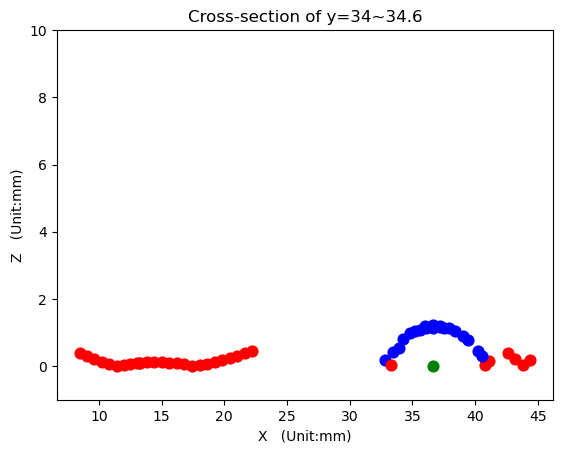

Accuracy is: 0.660377358490566
Center point of weld bead is: 36.64770905770989
Total height of weld bead is: 1.0464031561939762
---------------------------------------------------------------------
Data found successfully: data_set35


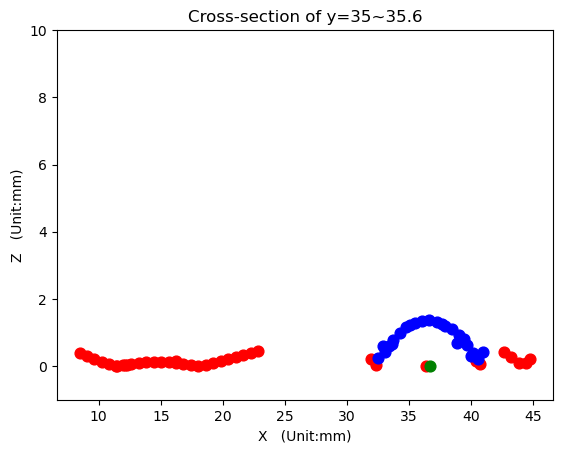

Accuracy is: 0.6825396825396826
Center point of weld bead is: 36.69960463386169
Total height of weld bead is: 1.1398157761234802
---------------------------------------------------------------------
Data found successfully: data_set36


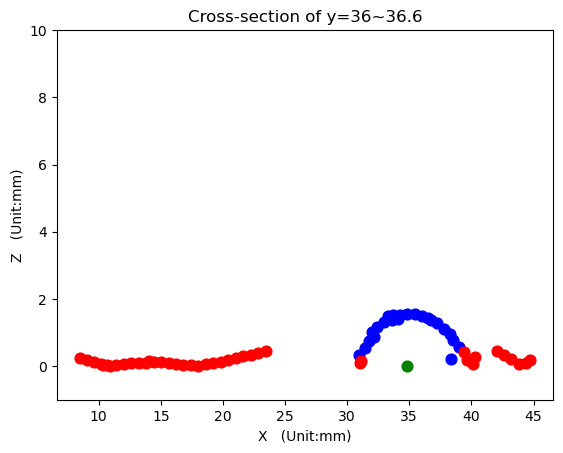

Accuracy is: 0.65625
Center point of weld bead is: 34.84756330517833
Total height of weld bead is: 1.3274512494884059
---------------------------------------------------------------------
Data found successfully: data_set37


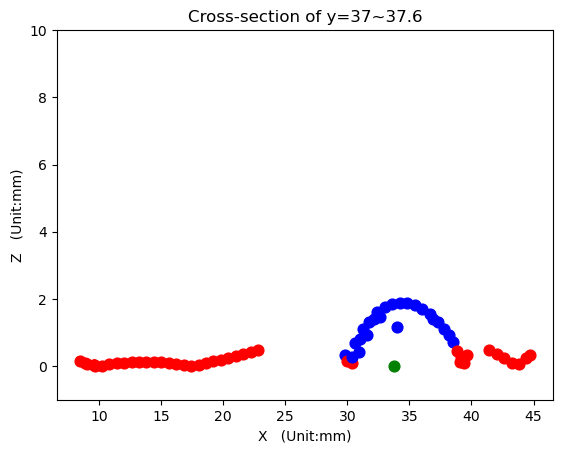

Accuracy is: 0.6119402985074627
Center point of weld bead is: 33.79174077048712
Total height of weld bead is: 1.5992190162112039
---------------------------------------------------------------------
Data found successfully: data_set38


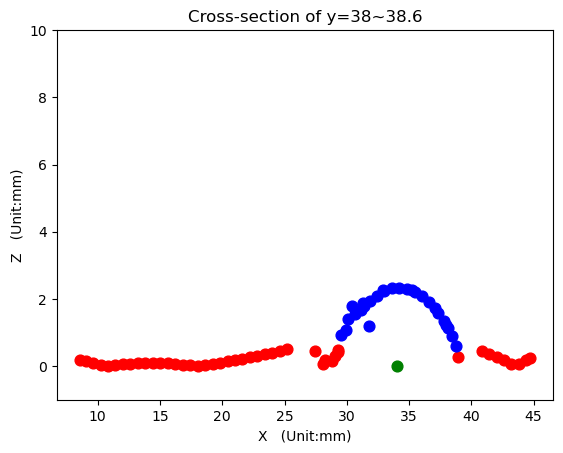

Accuracy is: 0.6527777777777778
Center point of weld bead is: 34.00358589936991
Total height of weld bead is: 1.719451475378279
---------------------------------------------------------------------
Data found successfully: data_set39


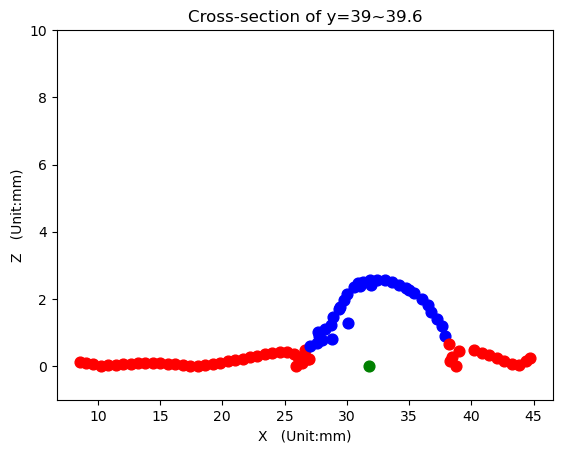

Accuracy is: 0.6626506024096386
Center point of weld bead is: 31.801830565891315
Total height of weld bead is: 1.970093147936831
---------------------------------------------------------------------
Data found successfully: data_set40


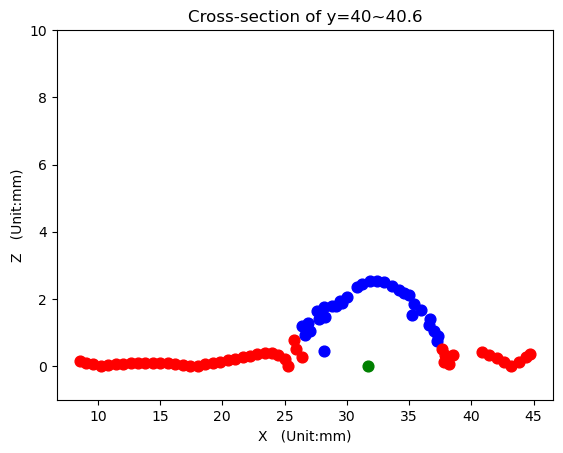

Accuracy is: 0.6103896103896104
Center point of weld bead is: 31.682805458433332
Total height of weld bead is: 2.071051160097289
---------------------------------------------------------------------
Data found successfully: data_set41


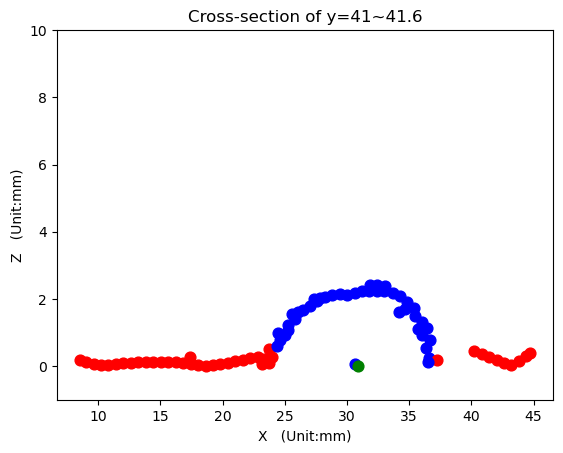

Accuracy is: 0.6746987951807228
Center point of weld bead is: 30.922357572603524
Total height of weld bead is: 2.3520244273352535
---------------------------------------------------------------------
Data found successfully: data_set42


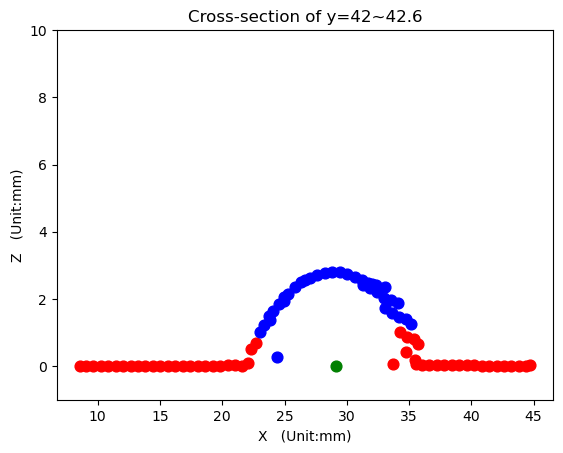

Accuracy is: 0.9069767441860465
Center point of weld bead is: 29.169943391216016
Total height of weld bead is: 2.5368781469318042
---------------------------------------------------------------------
Data found successfully: data_set43


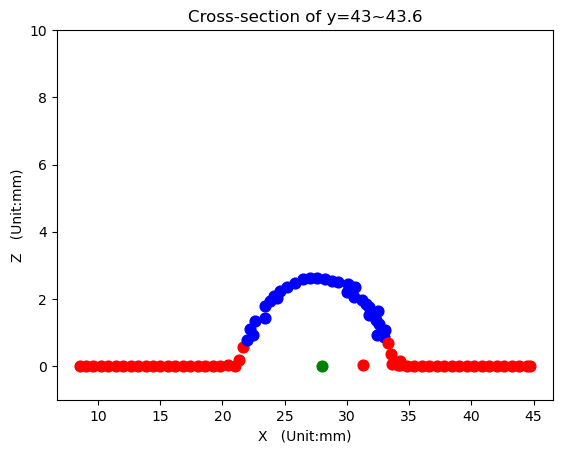

Accuracy is: 0.9382716049382716
Center point of weld bead is: 27.96514649448471
Total height of weld bead is: 1.8202793737258107
---------------------------------------------------------------------
Data found successfully: data_set44


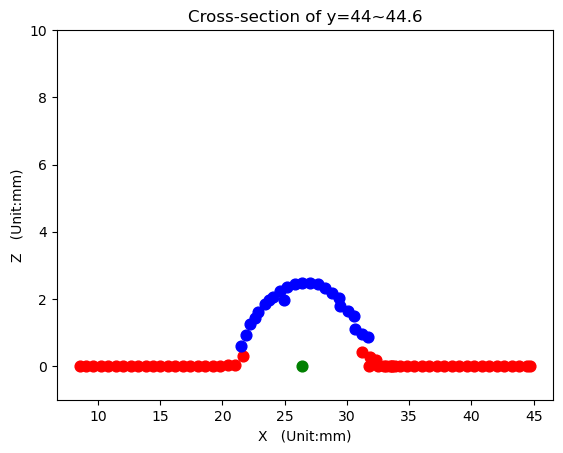

Accuracy is: 0.948051948051948
Center point of weld bead is: 26.420442789030986
Total height of weld bead is: 1.8710170071140393
---------------------------------------------------------------------
Data found successfully: data_set45


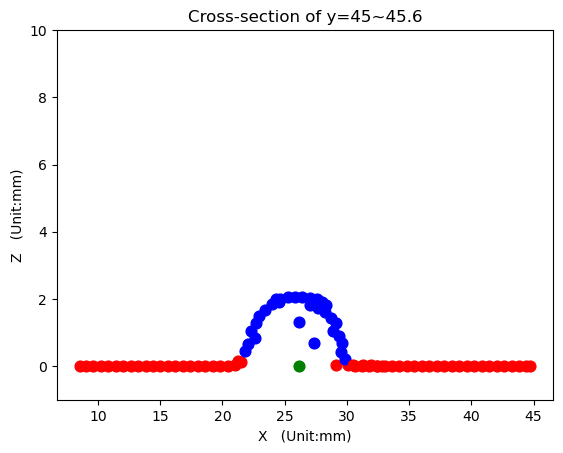

Accuracy is: 0.9767441860465116
Center point of weld bead is: 26.16574416310889
Total height of weld bead is: 1.8490158957976324
---------------------------------------------------------------------
Data found successfully: data_set46


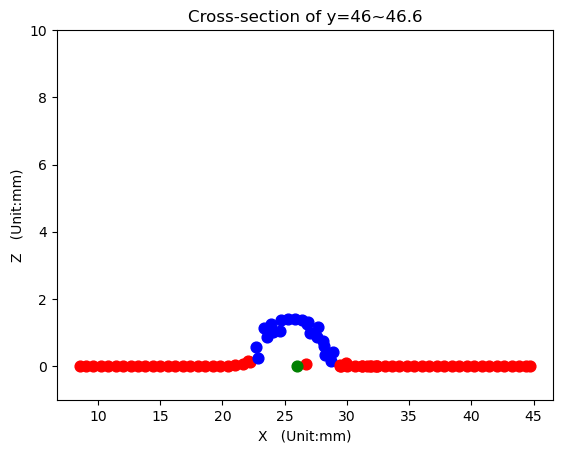

Accuracy is: 0.9761904761904762
Center point of weld bead is: 25.96670758613854
Total height of weld bead is: 1.2571622642229645
---------------------------------------------------------------------
Data found successfully: data_set47


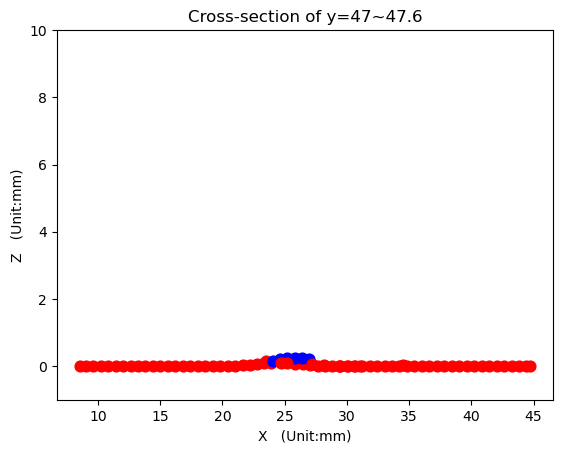

Accuracy is: 0.948051948051948
The maximum height is: 0.2530195124970227
No weld bead detected
---------------------------------------------------------------------
Data found successfully: data_set48


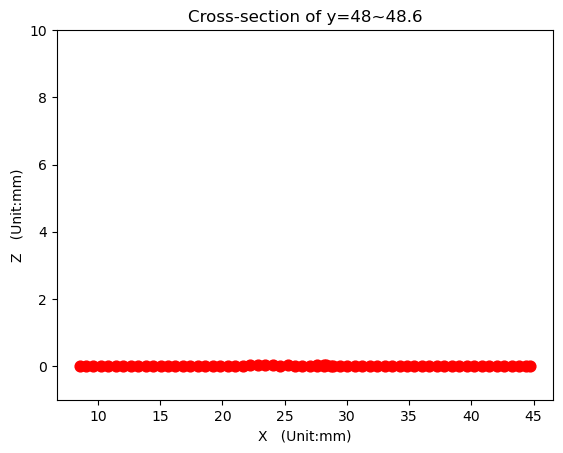

Accuracy is: 1.0
The maximum height is: 0.029004229843927476
No weld bead detected
---------------------------------------------------------------------
Data found successfully: data_set49


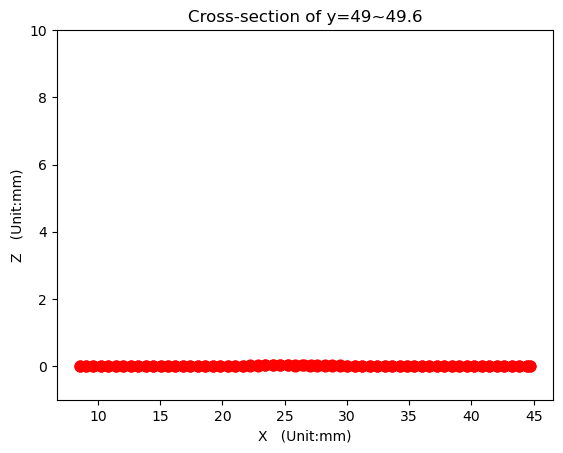

Accuracy is: 1.0
The maximum height is: 0.03525654930157973
No weld bead detected
---------------------------------------------------------------------
Data found successfully: data_set50


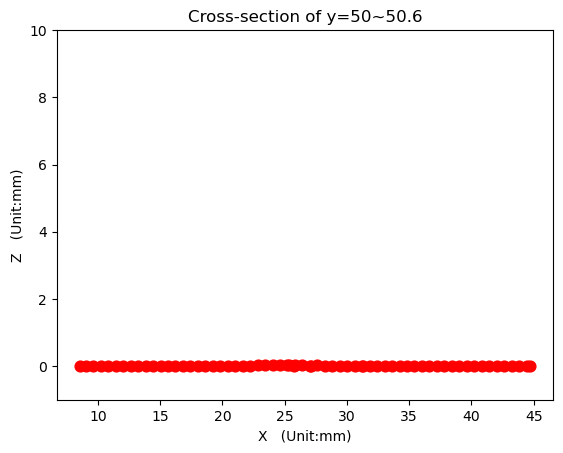

Accuracy is: 1.0
The maximum height is: 0.029152952825678535
No weld bead detected
---------------------------------------------------------------------
Data found successfully: data_set51


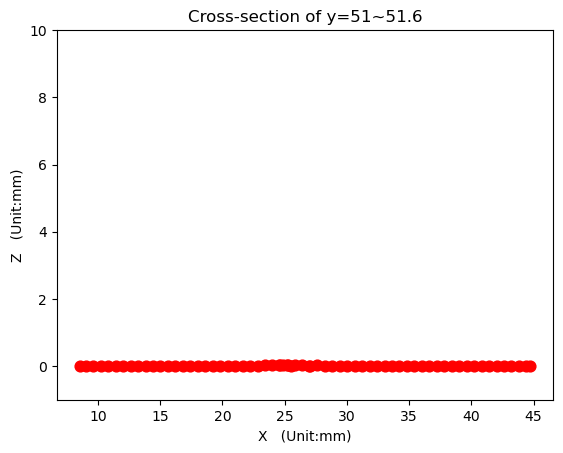

Accuracy is: 1.0
The maximum height is: 0.029592938332025587
No weld bead detected
---------------------------------------------------------------------
Data found successfully: data_set52


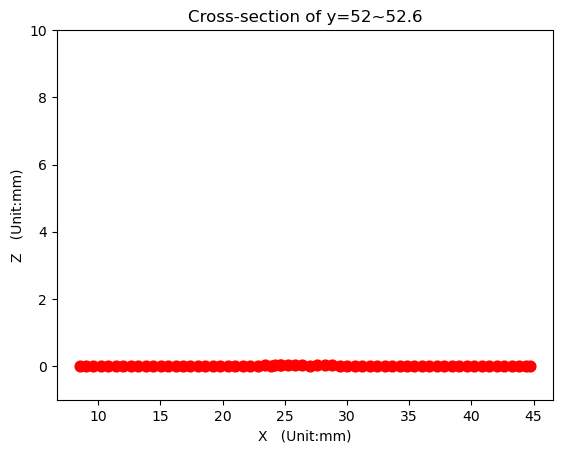

Accuracy is: 1.0
The maximum height is: 0.026221273177678528
No weld bead detected
---------------------------------------------------------------------
Data found successfully: data_set53


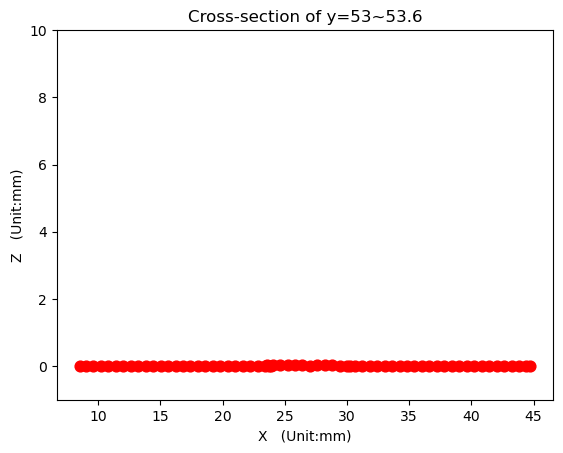

Accuracy is: 1.0
The maximum height is: 0.026179330246851373
No weld bead detected
---------------------------------------------------------------------
Data found successfully: data_set54


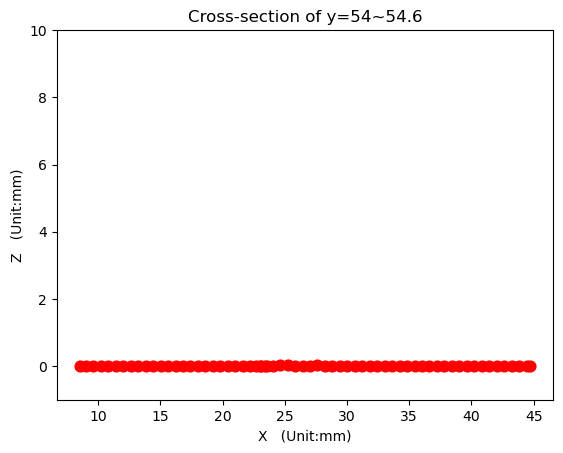

Accuracy is: 1.0
The maximum height is: 0.025529654051766548
No weld bead detected
---------------------------------------------------------------------
Data found successfully: data_set55


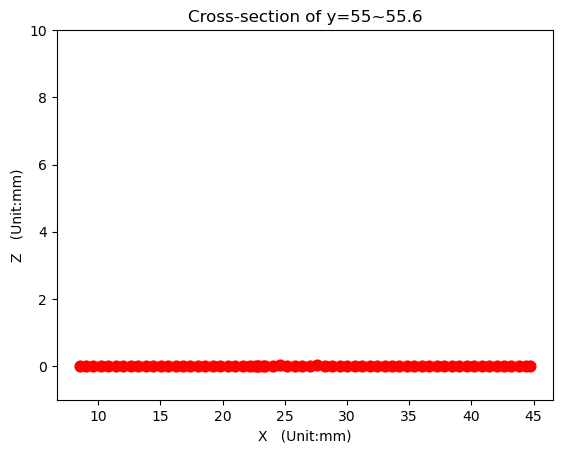

Accuracy is: 1.0
The maximum height is: 0.026210848749531168
No weld bead detected
---------------------------------------------------------------------
Data found successfully: data_set56


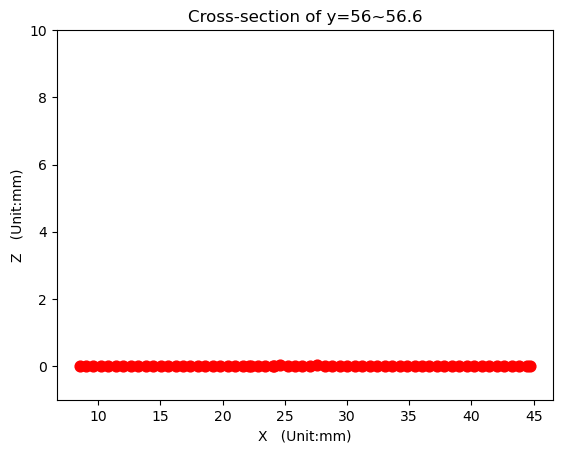

Accuracy is: 1.0
The maximum height is: 0.025595136926657602
No weld bead detected
---------------------------------------------------------------------
Data found successfully: data_set57


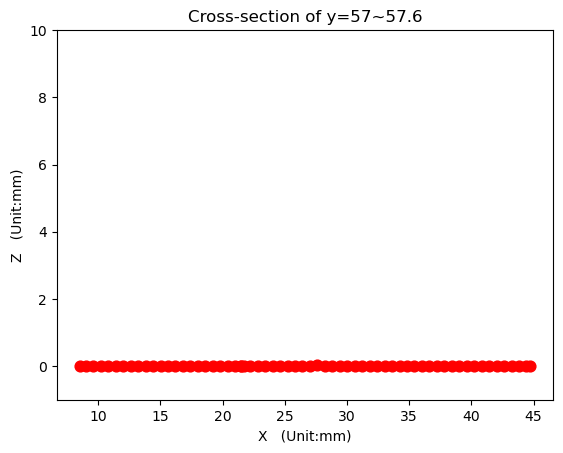

Accuracy is: 1.0
The maximum height is: 0.02342424291227463
No weld bead detected
---------------------------------------------------------------------
Data found successfully: data_set58


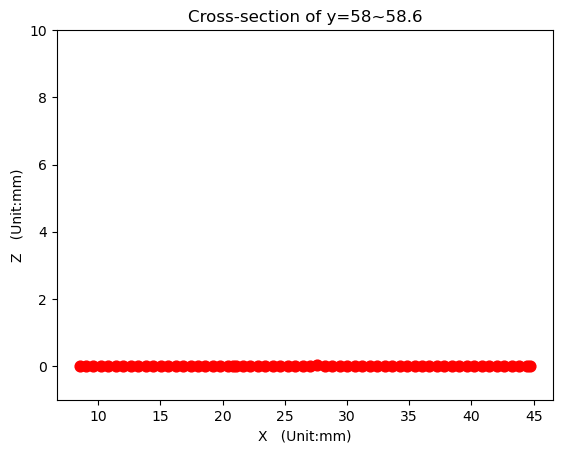

Accuracy is: 1.0
The maximum height is: 0.02183404940986844
No weld bead detected
---------------------------------------------------------------------
Data found successfully: data_set59


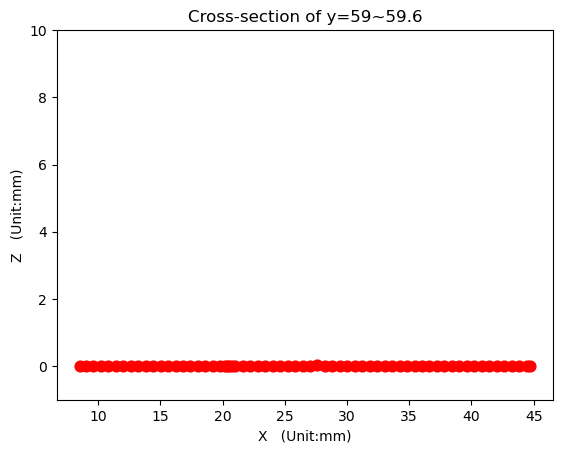

Accuracy is: 1.0
The maximum height is: 0.021424929895418776
No weld bead detected
---------------------------------------------------------------------
Data found successfully: data_set60


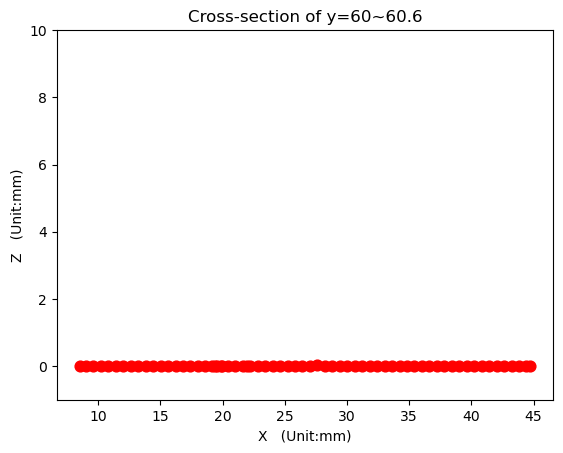

Accuracy is: 1.0
The maximum height is: 0.021942477147143258
No weld bead detected
---------------------------------------------------------------------
Data found successfully: data_set61


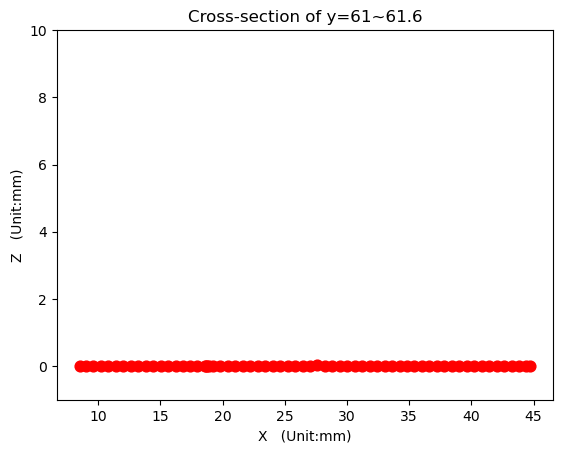

Accuracy is: 1.0
The maximum height is: 0.021663371768197548
No weld bead detected
---------------------------------------------------------------------
Data found successfully: data_set62


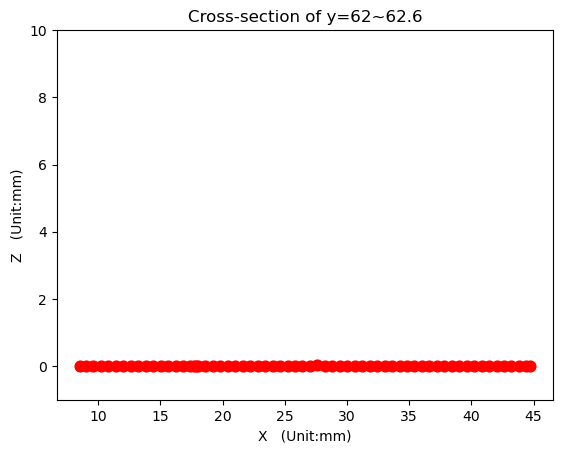

Accuracy is: 1.0
The maximum height is: 0.022386228701887667
No weld bead detected
---------------------------------------------------------------------
Data found successfully: data_set63


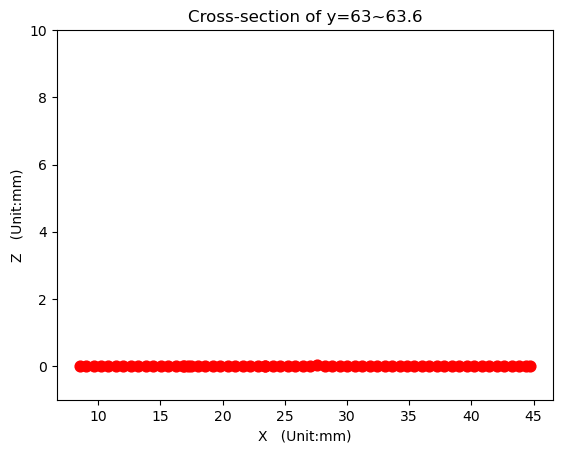

Accuracy is: 1.0
The maximum height is: 0.021811232744977982
No weld bead detected
---------------------------------------------------------------------
Data found successfully: data_set64


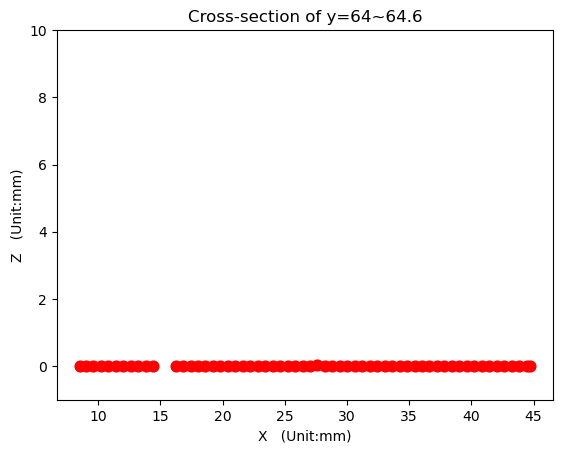

Accuracy is: 1.0
The maximum height is: 0.020656311038872666
No weld bead detected
---------------------------------------------------------------------
Weld bead detection completed!
Time consumed for detecting: 32.93762755393982 sec
The maximum height is: 2.5368781469318042
Mean accuracy is: 0.887630718368565


In [7]:
center_point = []
y_value_of_center_point = []
weld_bead_left_side = []
weld_bead_right_side = []
x_orig = []                               #x_orig、y_orig、z_orig、label_orig、path_height_orig用於儲存分類完並回復到曲線擬合前狀態的座標的點
y_orig = []
z_orig = []
label_orig = []
path_height_orig = []
accuracy = []
max_height_each_cross = []

all_max_h = []

time1 = time.time()

for a in range(0, n_section + 1, 1):
    if f'data_set{a}' in globals() and f'data_set{a}' != []:
        print('Data found successfully: data_set' + str(a))
        data = globals()[f'data_set{a}']
        X = data.iloc[0:, 1:6].values
        try:
            y = classifier.predict(X)
        except:
            continue

        x_data = data['x']
        z_data = data['h']
        label = y.tolist()

        curve = globals()[f'funcs{a}']
        
        for i in range(len(label)):                                          #畫預測完的銲道剖面
            if label[i] == 0:
                plt.scatter(x_data[i], z_data[i], s = 60, c = 'red')
#                 plt.scatter(x_data[i], z_data[i]+curve(x_data[i]), s = 60, c = 'black')
                x_orig.append(x_data[i])
                y_orig.append(a)
                z_orig.append(z_data[i] + np.abs(curve(x_data[i])))
                label_orig.append(label[i])
            elif label[i] == 1:
                plt.scatter(x_data[i], z_data[i], s = 60, c = 'blue')
#                 plt.scatter(x_data[i], z_data[i]+curve(x_data[i]), s = 60, c = 'black')
                x_orig.append(x_data[i])
                y_orig.append(a)
                z_orig.append(z_data[i] + np.abs(curve(x_data[i])))
                label_orig.append(label[i])

        plt.title("Cross-section of y="+str(a)+"~"+str(a+0.6))
        plt.ylim(-1, 10)
        plt.xlabel('X   (Unit:mm)')
        plt.ylabel('Z   (Unit:mm)')
        
        from sklearn.metrics import accuracy_score

        acc_test = accuracy_score(data.iloc[0:, 6].values, y)
        accuracy.append(acc_test)
        #print('Accuracy is: ' + str(acc_test))
      
        if acc_test >= 0.5 and label.count(1) > 7 and label.count(0) > 25: #準確率達到標準且資料點數量正常才判斷有銲道存在並進行分類
            weld_bead_x = []
            weld_bead_h = []
            workpiece_x = []
            workpiece_h = []

            for i in range(len(label)):                                     #標籤為0的分類為工件，標籤為1的分類為銲道
                if label[i] == 0:
                    workpiece_x.append(x_data[i])
                    workpiece_h.append(z_data[i])
                elif label[i] == 1:
                    weld_bead_x.append(x_data[i])
                    weld_bead_h.append(z_data[i])
            
            z_max_index = np.argmax(z_data)
            x_at_zmax = x_data[z_max_index]
            
            
#             for i in range(len(weld_bead_x)):                               #若判斷為銲道的點離最高點太遠則判斷不是銲道(剔除)
#                 if (x_at_zmax - min(weld_bead_x)) > 1.5*(max(weld_bead_x) - x_at_zmax):
#                     min_index = np.argmin(weld_bead_x)
#                     weld_bead_x = np.delete(weld_bead_x, min_index)
#                     weld_bead_h = np.delete(weld_bead_h, min_index)
                    
#                 elif (max(weld_bead_x) - x_at_zmax) > 1.5*(x_at_zmax - min(weld_bead_x)):
#                     max_index = np.argmax(weld_bead_x)
#                     weld_bead_x = np.delete(weld_bead_x, max_index)
#                     weld_bead_h = np.delete(weld_bead_h, max_index)
#                 else:
#                     continue

            
            weld_bead_width = max(weld_bead_x) - min(weld_bead_x)
            center_point_of_width = (max(weld_bead_x) + min(weld_bead_x))/2   
            weld_bead_height = max(weld_bead_h) - min(weld_bead_h)
            final_center_point = np.mean(weld_bead_x)                        #用所有銲道的點之x座標的平均值當銲道中心點
            #final_center_point = (center_point_of_width + x_at_zmax)/2      #用銲道寬度的中心點與銲道最高點的x平均值當銲道中心點
            center_point.append(final_center_point)
            y_value_of_center_point.append(a)
            weld_bead_left_side.append(min(weld_bead_x))
            weld_bead_right_side.append(max(weld_bead_x))
            max_height_each_cross.append(max(weld_bead_h))
            path_height_orig.append(max(weld_bead_h) + np.abs(curve(x_data[i])))  #將研磨路徑的高度還原成曲線擬合前狀態的高度 
            plt.scatter(final_center_point, 0, s = 60, c = 'green')
            plt.show()
            print('Accuracy is: ' + str(acc_test))   
            print("Center point of weld bead is: " + str(final_center_point))
            print("Total height of weld bead is: " + str(weld_bead_height))
            all_max_h.append(weld_bead_height)
            
        else:
            plt.show()
            print('Accuracy is: ' + str(acc_test))
            print('The maximum height is: ' + str(max(z_data)))
            print('No weld bead detected')
        print('---------------------------------------------------------------------')
    
    else:
        None

time2 = time.time()
print('Weld bead detection completed!')
print('Time consumed for detecting: ' + str(time2 - time1) + ' sec')
print('The maximum height is: ' + str(max(all_max_h)))
print('Mean accuracy is: ' + str(sum(accuracy)/len(accuracy)))

# 產生研磨路徑

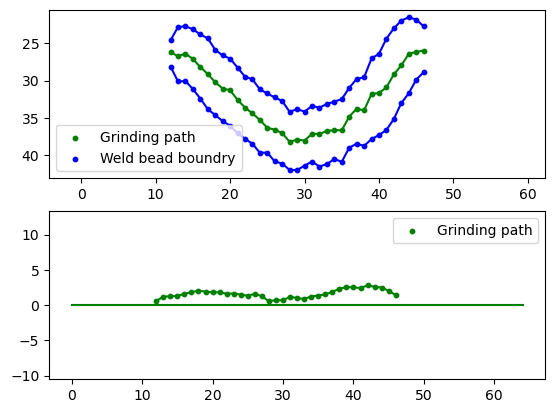

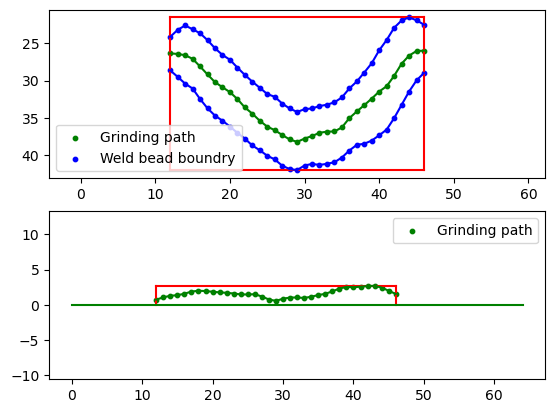

---------------------------------------------------------------------
Dimensions of containing block:      (Unit:mm)
Length: 34.6
Width: 20.463671957776718
Height: 2.692155678920022
Original center line: 26.522119140624994
Center line: 31.76255285257555
Axis offset: 5.240433711950555


In [8]:
#---------------------------------------------------------------------------------濾波前路徑圖
y_0 = [min(y_orig), max(y_orig)]
z_0 = [0, 0]
path_before_grinding = [min(y_orig), min(y_value_of_center_point)]
path_after_grinding = [max(y_value_of_center_point), max(y_orig)]

# plt.plot(path_before_grinding, [center_point[0], center_point[0]], c = 'green')
# plt.plot(path_after_grinding, [center_point[-1], center_point[-1]], c = 'green')
fig, (ax1, ax2) = plt.subplots(2, 1)
ax1.plot(y_value_of_center_point, center_point, c = 'green')
ax1.scatter(y_value_of_center_point, center_point, s = 10, label = "Grinding path", c = 'green')
ax1.plot(y_value_of_center_point, weld_bead_left_side, c = 'blue')
ax1.scatter(y_value_of_center_point, weld_bead_left_side, s = 10, label = "Weld bead boundry", c = 'blue')
ax1.plot(y_value_of_center_point, weld_bead_right_side, c = 'blue')
ax1.scatter(y_value_of_center_point, weld_bead_right_side, s = 10, c = 'blue')
#ax1.title('Grinding path of weld bead (Before filtering)')
#ax1.ylim(0, 60)
# ax1.xlabel('Y   (Unit:mm)')
# ax1.ylabel('X   (Unit:mm)')
ax1.axis('equal')
ax1.invert_yaxis()
ax1.legend()

ax2.plot(y_value_of_center_point, max_height_each_cross, c = 'green')
ax2.scatter(y_value_of_center_point, max_height_each_cross, s = 10, label = "Grinding path", c = 'green')
ax2.plot(y_0, z_0, c = 'green')
#ax2.title('Max height (Before filtering)')
#ax2.ylim(0, 60)
# ax2.xlabel('Y   (Unit:mm)')
# ax2.ylabel('Z   (Unit:mm)')
ax2.axis('equal')
ax2.legend()
plt.show()

#---------------------------------------------------------------------------------濾波後路徑圖
from scipy.signal import savgol_filter

center_point = savgol_filter(center_point, 5, 3, mode='nearest')
weld_bead_left_side = savgol_filter(weld_bead_left_side, 5, 3, mode='nearest')
weld_bead_right_side = savgol_filter(weld_bead_right_side, 5, 3, mode='nearest')
max_height_each_cross = savgol_filter(max_height_each_cross, 5, 3, mode='nearest')

# plt.plot(path_before_grinding, [center_point[0], center_point[0]], c = 'green')
# plt.plot(path_after_grinding, [center_point[-1], center_point[-1]], c = 'green')

fig, (ax3, ax4) = plt.subplots(2, 1)
ax3.plot([y_value_of_center_point[0], y_value_of_center_point[-1]], [max(weld_bead_right_side), max(weld_bead_right_side)], c = 'red')
ax3.plot([y_value_of_center_point[0], y_value_of_center_point[-1]], [min(weld_bead_left_side), min(weld_bead_left_side)], c = 'red')
ax3.plot([y_value_of_center_point[0], y_value_of_center_point[0]], [min(weld_bead_left_side), max(weld_bead_right_side)], c = 'red')
ax3.plot([y_value_of_center_point[-1], y_value_of_center_point[-1]], [min(weld_bead_left_side), max(weld_bead_right_side)], c = 'red')

ax3.plot(y_value_of_center_point, center_point, c = 'green')
ax3.scatter(y_value_of_center_point, center_point, s = 10, label = "Grinding path", c = 'green')
ax3.plot(y_value_of_center_point, weld_bead_left_side, c = 'blue')
ax3.scatter(y_value_of_center_point, weld_bead_left_side, s = 10, label = "Weld bead boundry", c = 'blue')
ax3.plot(y_value_of_center_point, weld_bead_right_side, c = 'blue')
ax3.scatter(y_value_of_center_point, weld_bead_right_side, s = 10, c = 'blue')
# plt.title('Grinding path of weld bead (After filtering)')
# plt.ylim(0, 60)
# plt.xlabel('Y   (Unit:mm)')
# plt.ylabel('X   (Unit:mm)')
ax3.axis('equal')
ax3.invert_yaxis()
ax3.legend()

ax4.plot([y_value_of_center_point[0], y_value_of_center_point[-1]], [max(max_height_each_cross), max(max_height_each_cross)], c = 'red')
ax4.plot([y_value_of_center_point[0], y_value_of_center_point[0]], [0, max(max_height_each_cross)], c = 'red')
ax4.plot([y_value_of_center_point[-1], y_value_of_center_point[-1]], [0, max(max_height_each_cross)], c = 'red')

ax4.plot(y_value_of_center_point, max_height_each_cross, c = 'green')
ax4.scatter(y_value_of_center_point, max_height_each_cross, s = 10, label = "Grinding path", c = 'green')
ax4.plot(y_0, z_0, c = 'green')
# plt.title('Max height (After filtering)')
# plt.ylim(0, 60)
# plt.xlabel('Y   (Unit:mm)')
# plt.ylabel('Z   (Unit:mm)')
ax4.axis('equal')
ax4.legend()
plt.show()

# #---------------------------------------------------------------------------------研磨平面偏轉角度
# d_angle = []
# for i in range(1, int(np.ceil(max(y_f))), 1):
#     if f'deflection_angle{i}' in globals():
#         d_angle.append(globals()[f'deflection_angle{i}'])
#         plt.scatter(i, globals()[f'deflection_angle{i}'], s = 30, c = 'red')
        
# params3 = np.polyfit(range(1, len(d_angle)+1, 1), d_angle, 5)
# funcs3 = np.poly1d(params3)
        
# plt.plot(range(1, len(d_angle)+1, 1), funcs3(range(1, len(d_angle)+1, 1)), c = 'blue')
# plt.title('Deflection angle of workpiece')
# plt.xlabel('Y   (Unit:mm)')
# plt.ylabel('Deflection angle   (Unit:Degree)')
# plt.xlim(-2, int(np.ceil(max(y_f)))+2)
# plt.show()

#---------------------------------------------------------------------------------包容塊尺寸
original_center_line = (max(x_f) + min(x_f))/2
center_line = (max(weld_bead_right_side) + min(weld_bead_left_side))/2
offset = center_line - original_center_line

print('---------------------------------------------------------------------')
print('Dimensions of containing block:      (Unit:mm)')
print('Length: ' + str(y_value_of_center_point[-1] - y_value_of_center_point[0] + 0.6))
print('Width: ' + str(max(weld_bead_right_side) - min(weld_bead_left_side)))
print('Height: ' + str(max(max_height_each_cross)))
print('Original center line: ' + str((max(x_f) + min(x_f))/2))
print('Center line: ' + str((max(weld_bead_right_side) + min(weld_bead_left_side))/2))
print('Axis offset: ' + str(offset))

0.07418761042976113
4.209100670830441


C:\Users\mmdl\.conda\envs\keras\lib\site-packages\ipykernel_launcher.py:3: MatplotlibDeprecationWarning: Axes3D(fig) adding itself to the figure is deprecated since 3.4. Pass the keyword argument auto_add_to_figure=False and use fig.add_axes(ax) to suppress this warning. The default value of auto_add_to_figure will change to False in mpl3.5 and True values will no longer work in 3.6.  This is consistent with other Axes classes.
  This is separate from the ipykernel package so we can avoid doing imports until


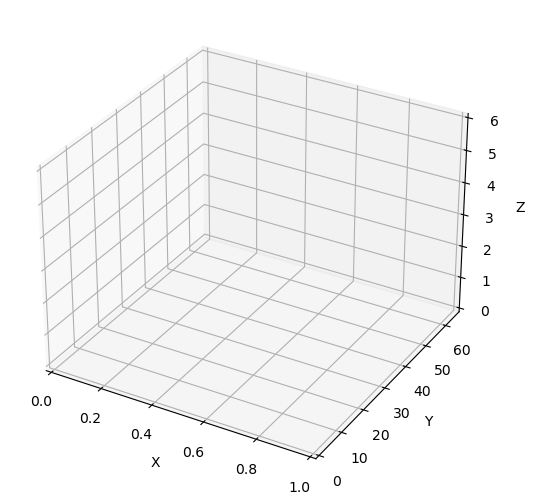

In [9]:
fig2 = plt.figure()    #創建圖形物件

ax2 = Axes3D(fig2)   #創建一個3D物件並加入到fig
fig2.add_axes(ax2)

# ax2.set_ylim([0, n_section + 0.6])   #座標比例尺
ax2.set_ylim([0, 65 + 0.6])
ax2.set_zlim([0, 6])
#****

ax2.set_xlabel("X")
ax2.set_ylabel("Y")
ax2.set_zlabel("Z")

min_h = np.min(z_orig)
max_h = np.max(z_orig)
print(min_h)
print(max_h)

# ax2.plot([max(weld_bead_right_side), max(weld_bead_right_side)], [y_value_of_center_point[0], y_value_of_center_point[-1]], [max_h, max_h], c = 'green')
# ax2.plot([min(weld_bead_left_side), min(weld_bead_left_side)], [y_value_of_center_point[0], y_value_of_center_point[-1]], [max_h, max_h], c = 'green')
# ax2.plot([min(weld_bead_left_side), max(weld_bead_right_side)], [y_value_of_center_point[0], y_value_of_center_point[0]], [max_h, max_h], c = 'green')
# ax2.plot([min(weld_bead_left_side), max(weld_bead_right_side)], [y_value_of_center_point[-1], y_value_of_center_point[-1]], [max_h, max_h], c = 'green')

# ax2.plot([max(weld_bead_right_side), max(weld_bead_right_side)], [y_value_of_center_point[0], y_value_of_center_point[-1]], [min_h, min_h], c = 'green')
# ax2.plot([min(weld_bead_left_side), min(weld_bead_left_side)], [y_value_of_center_point[0], y_value_of_center_point[-1]], [min_h, min_h], c = 'green')
# ax2.plot([min(weld_bead_left_side), max(weld_bead_right_side)], [y_value_of_center_point[0], y_value_of_center_point[0]], [min_h, min_h], c = 'green')
# ax2.plot([min(weld_bead_left_side), max(weld_bead_right_side)], [y_value_of_center_point[-1], y_value_of_center_point[-1]], [min_h, min_h], c = 'green')

# ax2.plot([max(weld_bead_right_side), max(weld_bead_right_side)], [y_value_of_center_point[0], y_value_of_center_point[0]], [max_h, min_h], c = 'green')
# ax2.plot([min(weld_bead_left_side), min(weld_bead_left_side)], [y_value_of_center_point[0], y_value_of_center_point[0]], [max_h, min_h], c = 'green')
# ax2.plot([max(weld_bead_right_side), max(weld_bead_right_side)], [y_value_of_center_point[-1], y_value_of_center_point[-1]], [max_h, min_h], c = 'green')
# ax2.plot([min(weld_bead_left_side), min(weld_bead_left_side)], [y_value_of_center_point[-1], y_value_of_center_point[-1]], [max_h, min_h], c = 'green')

# for i in range(len(label_orig)):  #畫分類後的圖
#     if label_orig[i] == 0:
#         ax2.scatter(x_orig[i], y_orig[i], z_orig[i], c ='blue', alpha=0.07)
#     elif label_orig[i] == 1:
#         ax2.scatter(x_orig[i], y_orig[i], z_orig[i], c ='red', alpha=0.07)


# for i in range(len(x_f)):         #畫分類前的圖
#     ax2.scatter(x_f[i], y_f[i], z_f[i], c ='black')

     # ax2.scatter(center_point, y_value_of_center_point, path_height_orig, c ='green') ##畫路徑圖
# ax2.set_box_aspect([1,1,1])
# plt.show()

In [10]:
# for i in range(len(label_orig)):  #畫分類後的圖
#     if label_orig[i] == 0:
#         plt.scatter(x_orig[i], y_orig[i], c ='red')
#     elif label_orig[i] == 1:
#         plt.scatter(x_orig[i], y_orig[i], c ='blue')
        
# plt.axis('equal')
# plt.show()

In [11]:
# from socket import *

# tcpSerSock = socket(AF_INET, SOCK_STREAM)
# tcpSerSock.bind(('192.168.1.10', 8080))
# tcpSerSock.listen(5)

# while True:
#     print('Waiting for connection...')
#     tcpCliSock, addr = tcpSerSock.accept()
#     print('...connecting from:', addr)
#     data_recv = tcpCliSock.recv(1024)
#     print(data_recv.decode())
    
#     while True:
#         X = str(offset)
#         tcpCliSock.send(X.encode('utf-8'))
#         break
#     while True:
#         Y = str(0)
#         tcpCliSock.send(Y.encode('utf-8'))
#         break
#     while True:
#         Z = str(0)
#         tcpCliSock.send(Z.encode('utf-8'))
#         break

<function matplotlib.pyplot.show(close=None, block=None)>

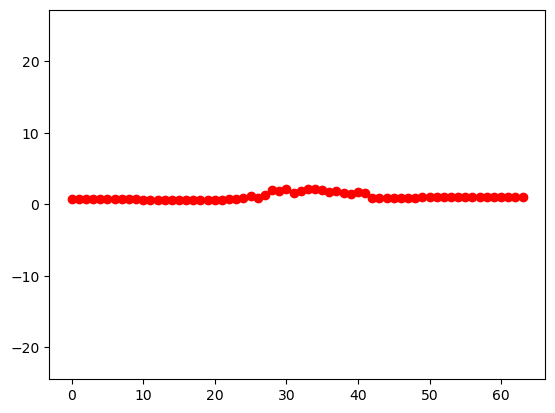

In [12]:
import re

# 获取当前全局命名空间中的所有函数名
all_funcs = [name for name in globals() if re.match(r'^funcs\d+$', name)]

# 提取函数名中的数字，并找出最大值
max_num = max(int(re.search(r'\d+', name).group()) for name in all_funcs)

z_wp = []
for b in range(0, max_num, 1):    
    z_wp.append(globals()[f'funcs{b}']((max(weld_bead_right_side) + min(weld_bead_left_side))/2))

    
plt.scatter(range(0, max_num), z_wp, c = 'red')
plt.axis('equal')
plt.show
